# [LAB-03] 지도학습-예측모델ㅣ02-탐색적 데이터 분석(실습코드).ipynb

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame 
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 품질 점검 완료 데이터셋 불러오기 

In [2]:
origin = load_data("california_housing_qtcheck")
num_desc = load_data("california_housing_numerical_summary")    
cat_desc = load_data("california_housing_categorical_summary")

📚 캘리포니아 주택 가격 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field               description
--  ------------------  --------------
 0  longitude           경도
 1  latitude            위도
 2  housing_median_age  주택 중위 연령
 3  total_rooms         총 방 수
 4  total_bedrooms      총 침실 수
 5  population          인구
 6  households          가구 수
 7  median_income       중위 소득
 8  median_house_value  주택 중위 가격
 9  ocean_proximity     해양 근처 위치

📚 캘리포니아 주택 가격 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 캘리포니아 주택 가격 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


### 3. 타입변환 (범주형 확정)
범주형 기술통계량 표의 컬럼명이 범주형 목록이다. 

In [3]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


### 4. 서열 척도 적용 (필요한 경우만)
범주형 범주에 대해서 서열척도를 적용할 변수에 대한 타입변환\
도메인 지식이 필요하다 

서열척도를 적용하지 앟더라도 모델링에 영향을 주지는 않는다\
시각화 출력 순서 유지 등을 위해서 처리 

In [4]:
# 서열척도를 적용할 변수와 순서를 정한다 (낮은등급 -> 높은등급)
# -> 도메인 지식이 필요한 부분이므로 #01 (준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다 
ordinal_map = {}

# 정의된 내용에 따라 순서르 재지정한다 
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다 
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


### 5. 변수 유형 분류 

In [6]:
target = "median_house_value" # 종속변수 이름    
target_is_continuous = True # 종속변수 연속형 여부 

# 분석 대상에서 제외할 변수
# -> 식별자(ID), 다른 변수와 중복되는 항목, 일반 변수로 다룰 수 없는 값 등을 나열한다
# -> 이번 데이터셋에서는 위경도가 여기에 해당한다
exclude_cols = ["longitude", "latitude"]

nominal_cols = my_qtcheck.get_categorical_column_names(df) # 범주형 변수
continuous_cols = my_qtcheck.get_number_column_names(df) # 연속형 변수

if target_is_continuous:           # 종속변수가 연속형 변수라면 ?
    continuous_cols.remove(target) # 연속형 변수 이름에서 종속변수 항목 제거 
else:                              # 종속변수가 범주형 변수라면?
    nominal_cols.remove(target)    # 범주형 변수 이름에서 종속변수 항목 제거 

# 제외 대상으로 지정한 변수를 각 목록에서 제거한다 
# -> 범주형에도 적용하므로 제외 대상이 범주형인 경우에도 그대로 동작한다. 
continuous_cols = [c for c in continuous_cols if c not in exclude_cols] 
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]   

print("종속변수: ", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "범주형"))
print("범주형: ", nominal_cols)
print("연속형: ", continuous_cols)
print("제외: ", exclude_cols)

종속변수:  median_house_value
종속변수 유형: 연속형
범주형:  ['ocean_proximity']
연속형:  ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
제외:  ['longitude', 'latitude']


### 6. 컬럼 의미를 정리한 딕셔너리 

In [7]:
column_means = {
    "median_house_value": "주택 중위 가격 (USD)",
    "longitude": "경도", 
    "latitude": "위도",
    "housing_median_age": "주택 중위 연령", 
    "total_rooms": "총 방 수", 
    "total_bedrooms": "총 침실 수", 
    "population": "인구",
    "households": "가구 수",
    "median_income": "중위 소득", 
    "ocean_proximity": "해양 근접도"
}

### 7. EDA 범위 정리 
종속유형	독립유형	분석 유형	대상 변수	적용 여부	비고
연속형	연속형	상관분석	연속형 독립변수 6종 → median_house_value	적용	종속·설명 모두 연속형
연속형	범주형(2집단)	T검정	-	미적용	2집단 범주형 없음
연속형	범주형(3집단+)	ANOVA	ocean_proximity → median_house_value	적용	5집단 범주형 1종
범주형(2집단)	연속형	T검정	-	미적용	종속변수 타입이 연속형
범주형(2집단)	범주형(2집단)	교차분석	-	미적용	종속변수 타입이 연속형
범주형(2집단)	범주형(3집단+)	교차분석	-	미적용	종속변수 타입이 연속형
범주형(3집단+)	연속형	ANOVA	-	미적용	종속변수 타입이 연속형
범주형(3집단+)	범주형(2집단)	교차분석	-	미적용	종속변수 타입이 연속형
범주형(3집단+)	범주형(3집단+)	교차분석	-	미적용	종속변수 타입이 연속형
종속변수 median_house_value가 연속형이므로 EDA 범위 표에서 상위 3개 행만 후보 → 2진 범주형이 없으므로 T검정 제외
연속형 독립변수 6종: housing_median_age, total_rooms, total_bedrooms, population, households, median_income
범주형 독립변수 1종: ocean_proximity (5개 범주) — 2집단이 아니므로 ANOVA 수행
longitude, latitude 2종은 exclude_cols에 지정해 EDA 대상에서 제외

위·경도를 제외한 이유

위·경도는 하나의 개별 값이 아니라 두 값이 함께 만드는 좌표 정보이다.
단순 관계가 아니므로, 상관계수·왜도·이상치처럼 변수를 하나씩 보는 진단으로는 신호를 잡을 수 없다.
그러므로 표준 연속형 트랙에서 빼고, 공간자기상관 검정으로 공간 구조의 존재를 확인한 뒤 좌표를 군집화해 공간특성 변수로 다시 투입해야 한다.

# 2-2 단변량 분석 

## #02. 단변량 분석 
### 1. 연속형 종속 변수에 대한 단변량 분석 

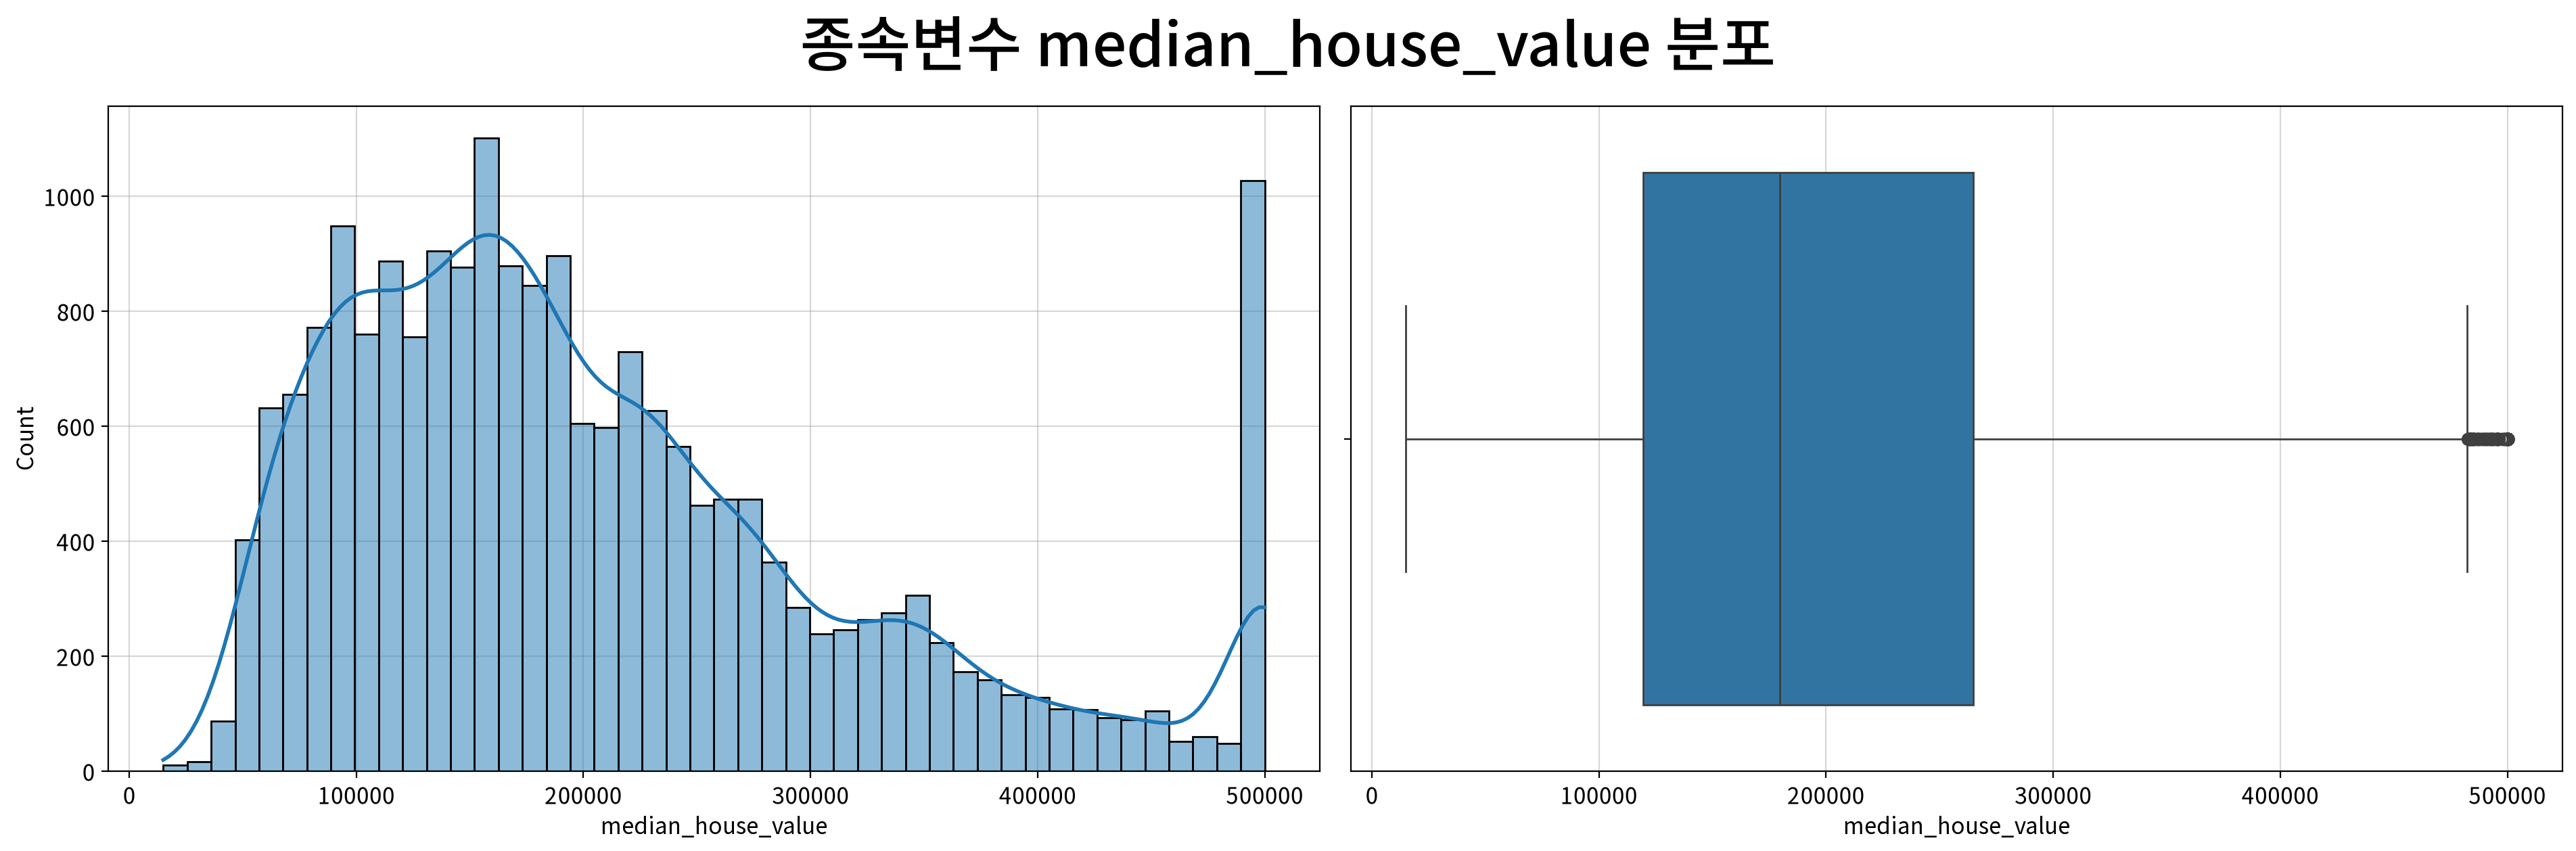

,median_house_value
count,20433.000
mean,206864.413
std,115435.667
min,14999.000
25%,119500.000
50%,179700.000
75%,264700.000
max,500001.000
rel_diff,0.151
rdiff_flag,diff


In [8]:
# 1행 2열 서브플롯 구성 
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출 
num_desc[num_desc.index == target].T

종속변수 분포 (주택 중위 가격: USD)
□ median_house_value

◎ 우편향 → 분포의 성질이 아니라 상한 절단이라는 기록 방식에 기인함.

점검 항목	결과
왜도·첨도	왜도 +0.978 (우편향), 첨도 +0.328
중심 지표	중앙값 179,700
,
평균
206
,
864
,평균206,864
이상치	상단 1,064건(5.2%), 하단 0건
이산점	500,001$ 한 값에 958건(4.7%) — 상단 이상치 1,064건 중 958건이 이 값에 해당함
정규성 판정	좌우 대칭이 아니며 로그 변환 검토 대상임

## #02. 단변량 분석 
### 2. 연속형 독립변수에 대한 단변량 분석 
반복문을 통해 모든 연속형 변수에 대해 시각화와 기술 통계량을 일괄 생성한다. 

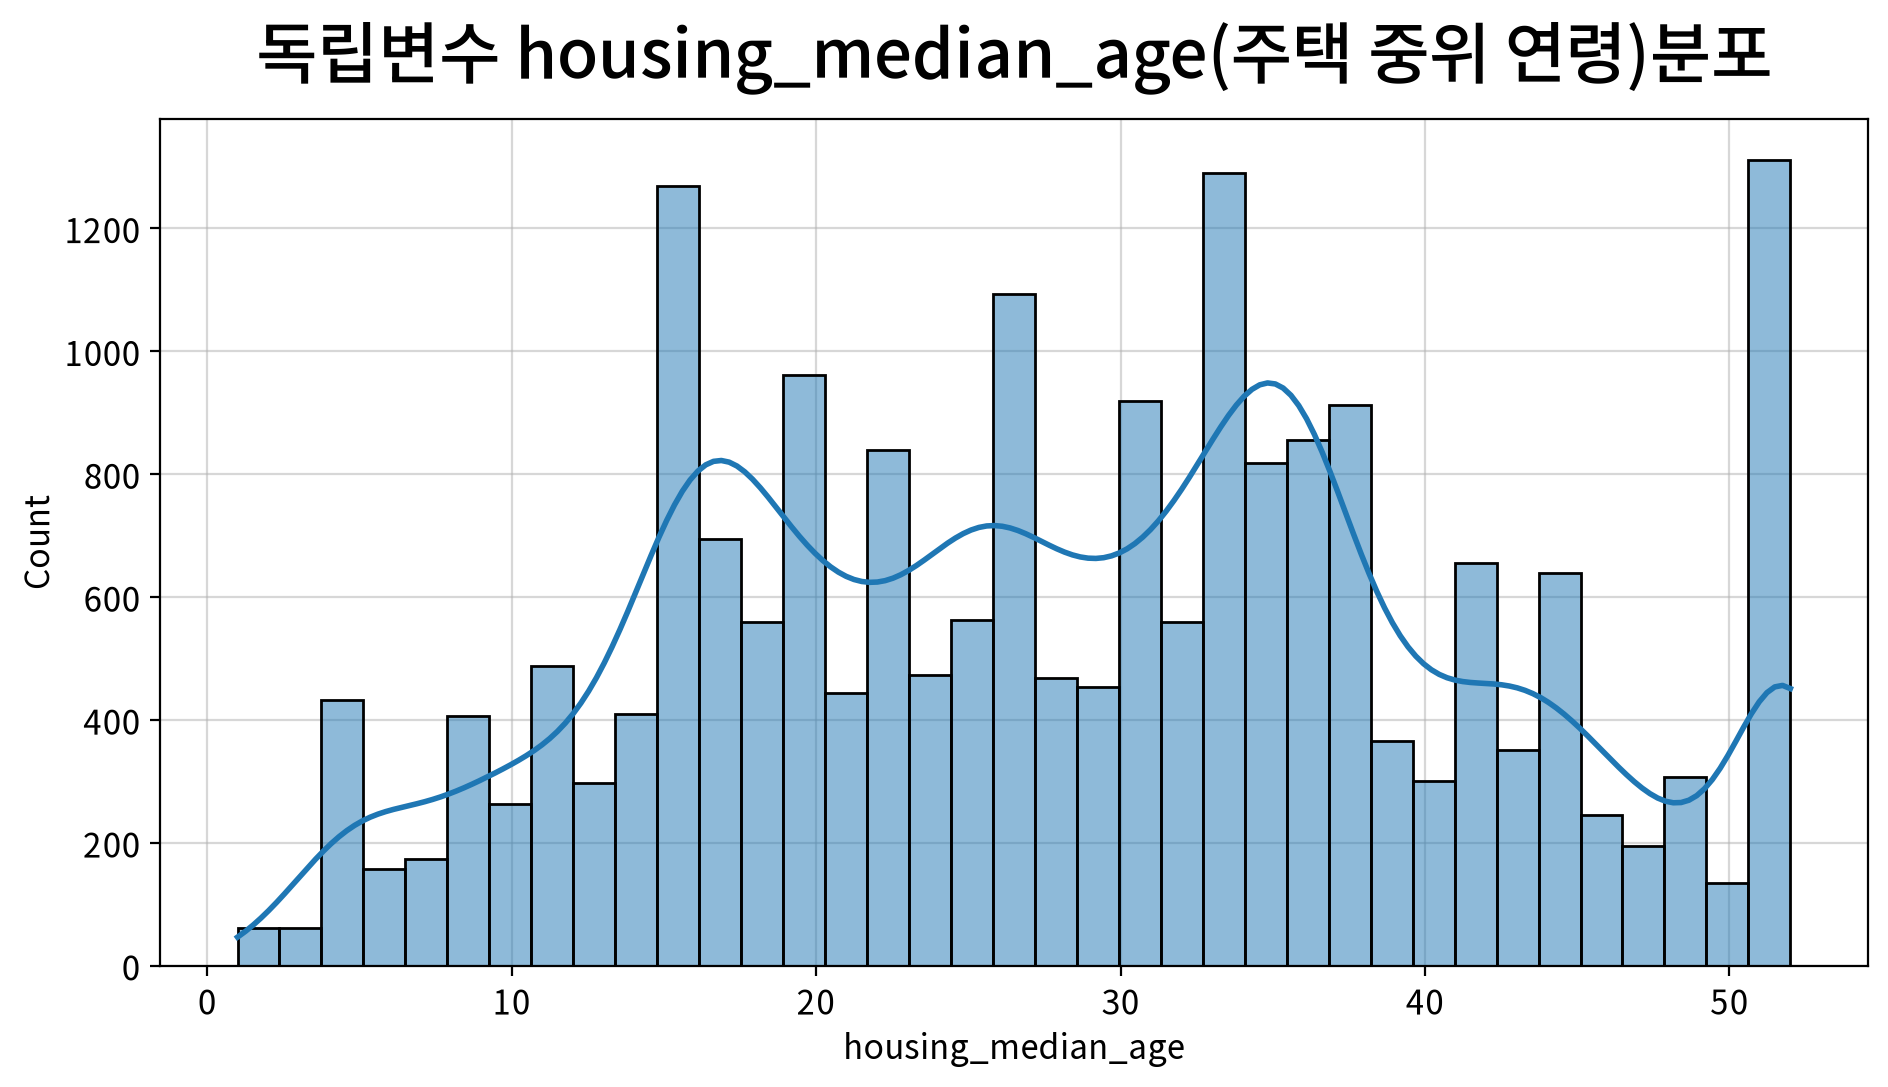

,housing_median_age
count,20433.000
mean,28.633
std,12.592
min,1.000
25%,18.000
50%,29.000
75%,37.000
max,52.000
rel_diff,0.013
rdiff_flag,similar


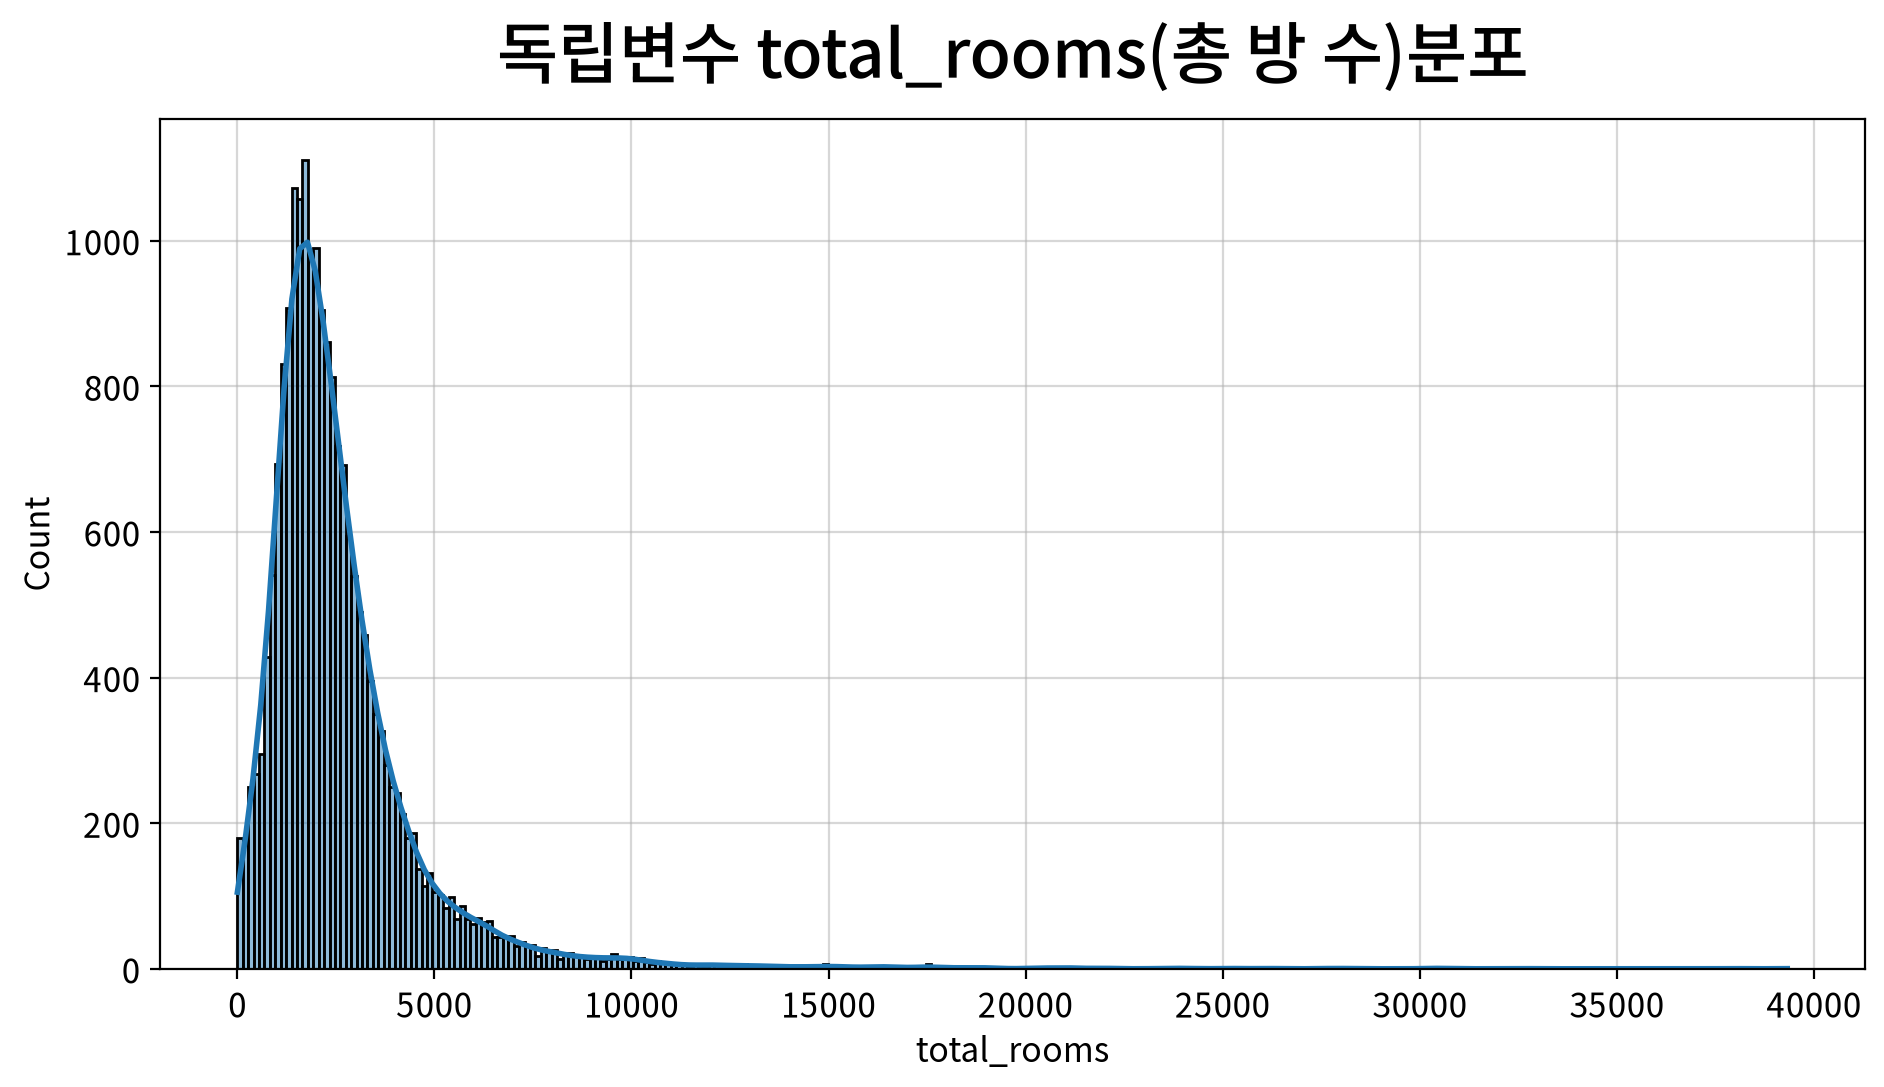

,total_rooms
count,20433.000
mean,2636.504
std,2185.270
min,2.000
25%,1450.000
50%,2127.000
75%,3143.000
max,39320.000
rel_diff,0.240
rdiff_flag,diff


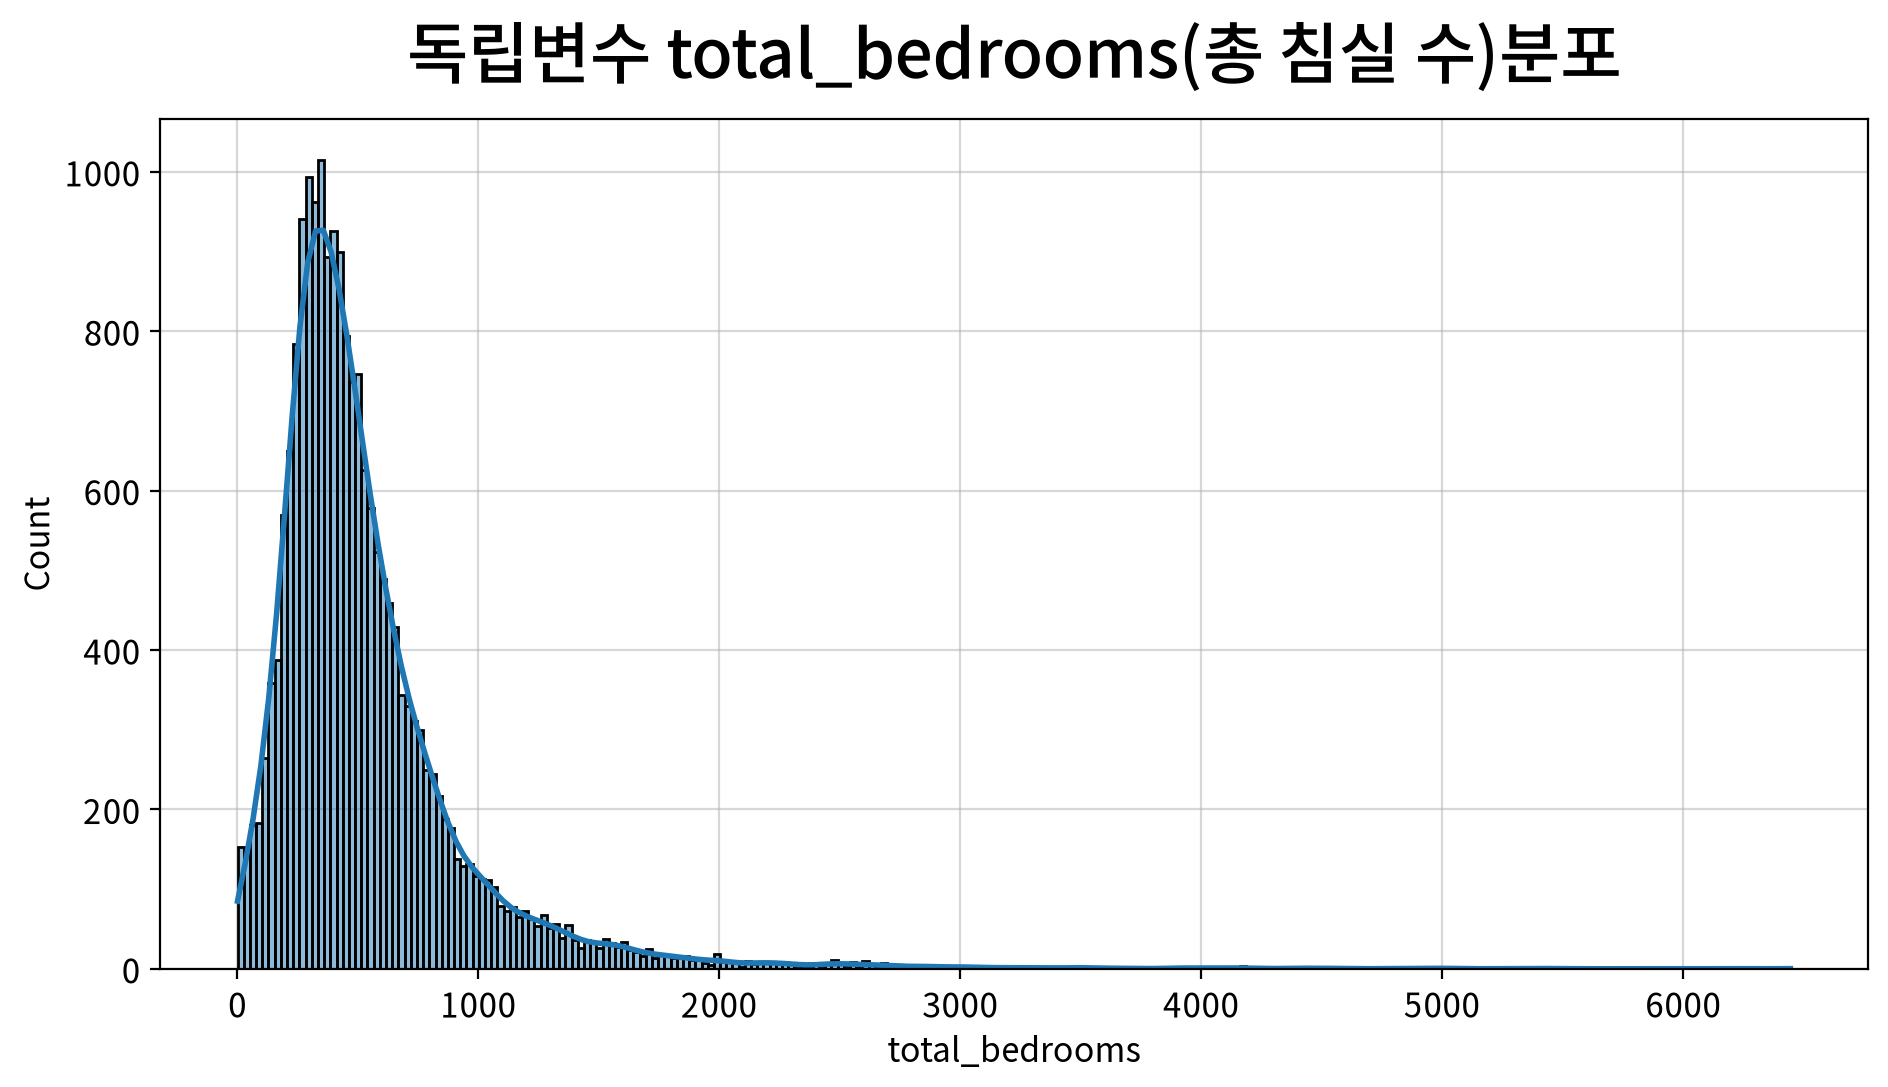

,total_bedrooms
count,20433.000
mean,537.871
std,421.385
min,1.000
25%,296.000
50%,435.000
75%,647.000
max,6445.000
rel_diff,0.236
rdiff_flag,diff


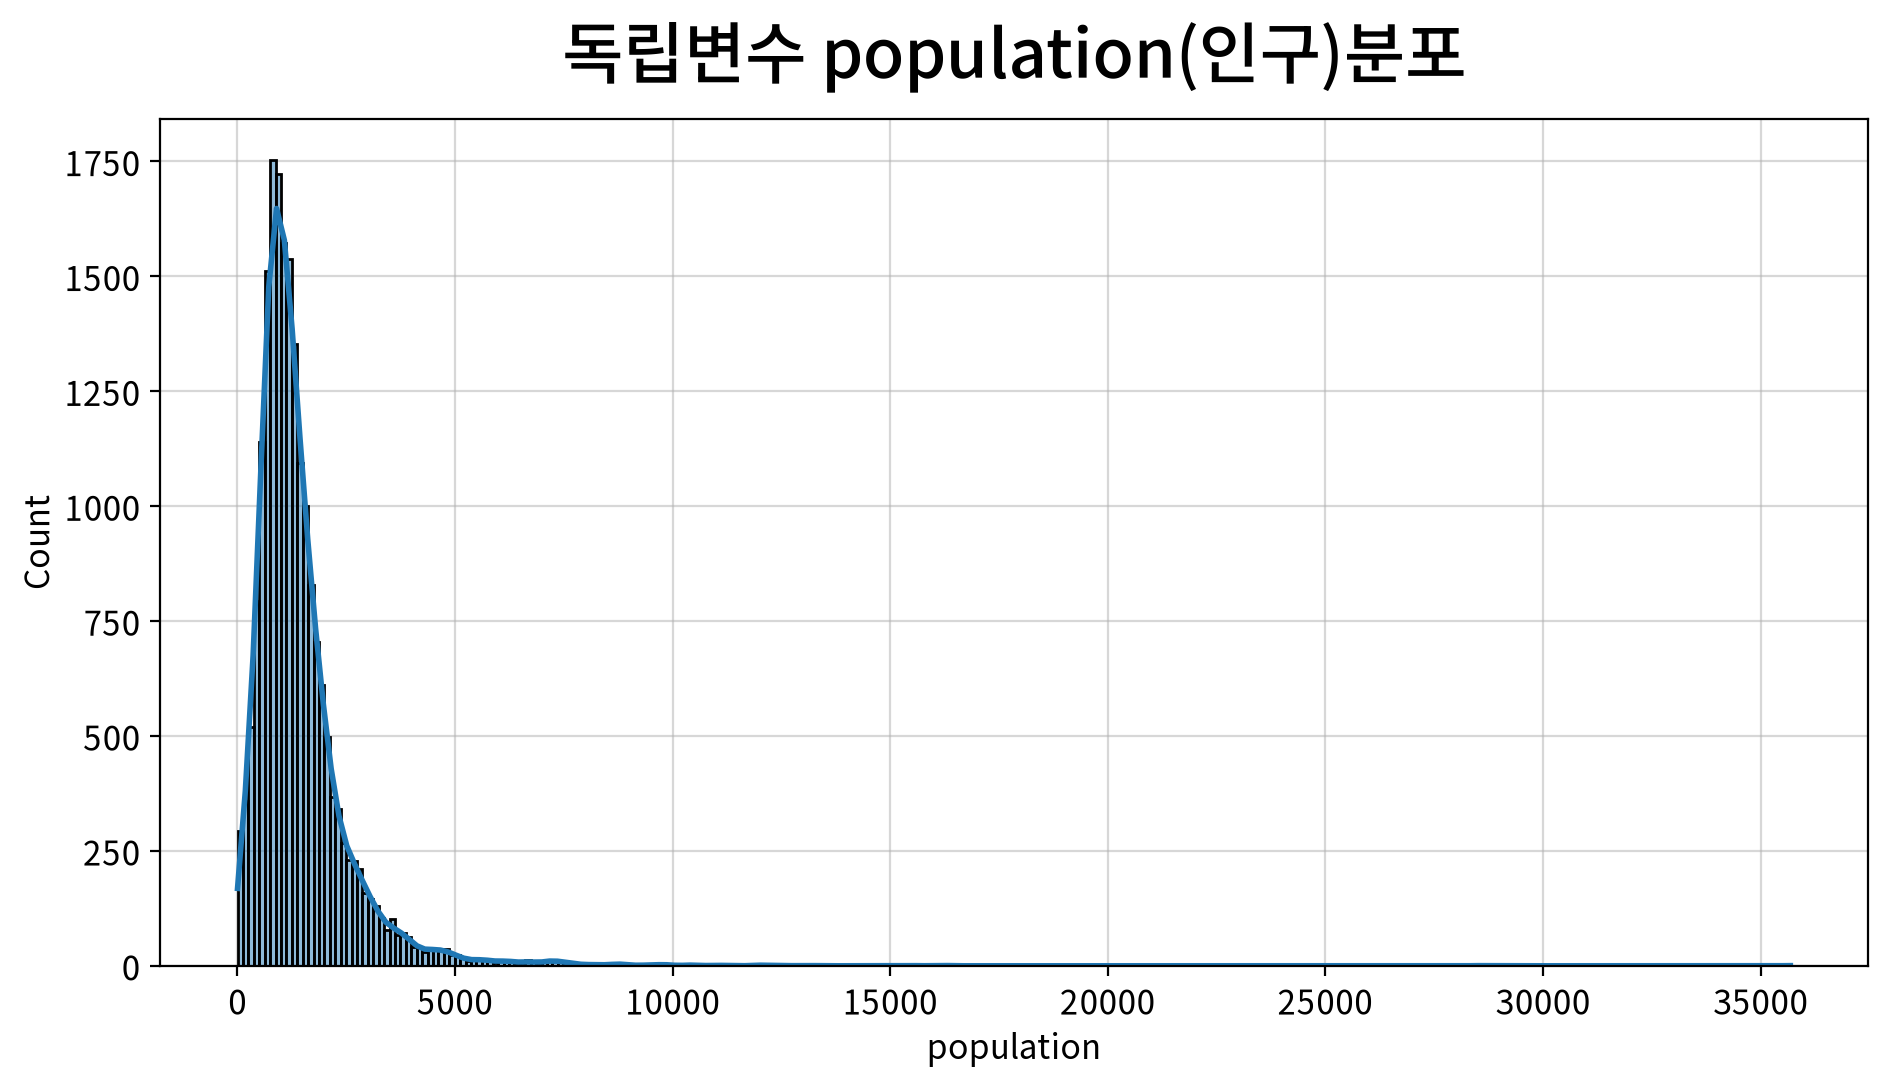

,population
count,20433.000
mean,1424.947
std,1133.208
min,3.000
25%,787.000
50%,1166.000
75%,1722.000
max,35682.000
rel_diff,0.222
rdiff_flag,diff


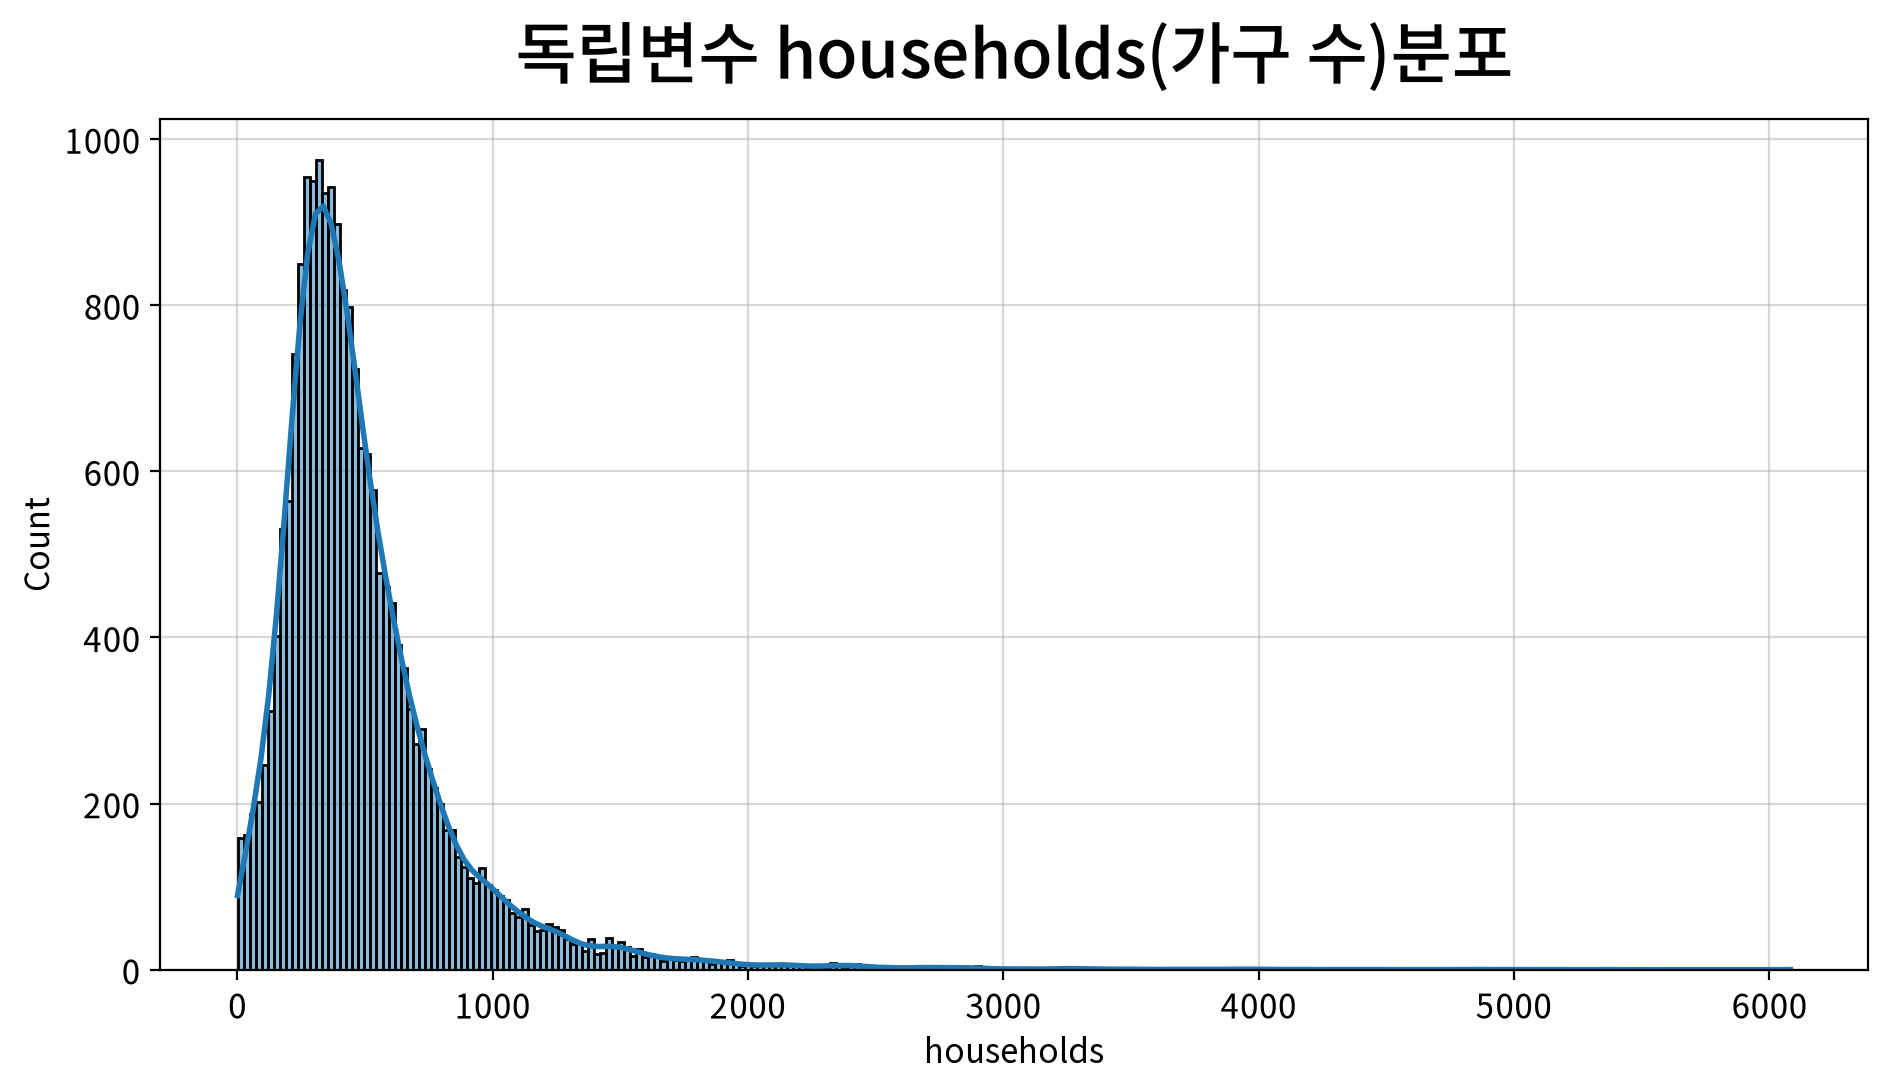

,households
count,20433.000
mean,499.433
std,382.299
min,1.000
25%,280.000
50%,409.000
75%,604.000
max,6082.000
rel_diff,0.221
rdiff_flag,diff


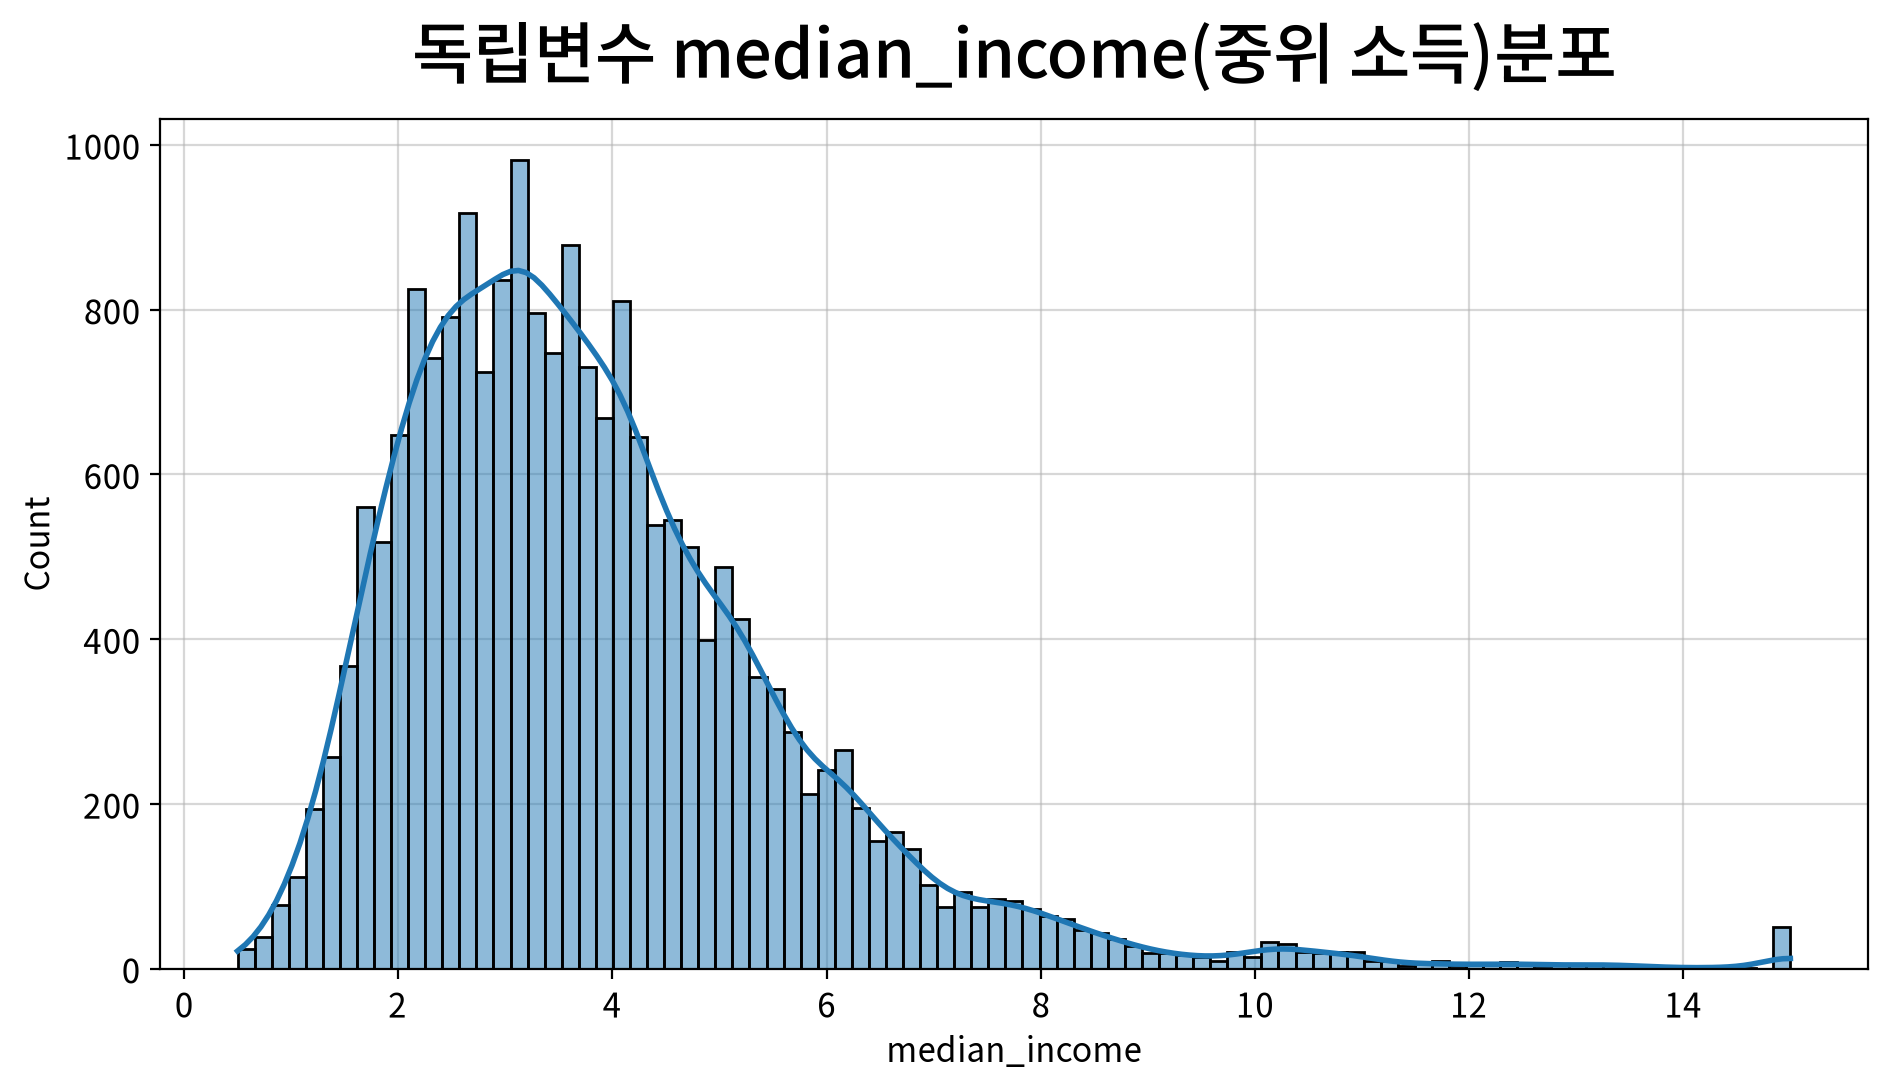

,median_income
count,20433.000
mean,3.871
std,1.899
min,0.500
25%,2.564
50%,3.537
75%,4.744
max,15.000
rel_diff,0.095
rdiff_flag,similar


In [9]:
for f in continuous_cols:
    # 히스토그램 및 박스플롯을 1행 2열 서브플롯으로 구성하는 경우
    # fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640, 
    #                   title=f"독립변수 {f}({column_means[f]}) 분포")
    # my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    # my_plot.boxplot(data=df, x=f, ax=ax[1])
    # my_plot.show()

    # 히스토그램만 그리는 경우 
    my_plot.histplot(data=df, x=f, kde=True, width=960, height=560,
                     title=f"독립변수 {f}({column_means[f]})분포")

    display(num_desc[num_desc.index == f].T)

연속형 독립변수 (1) - 주택 중위 연령, 총 방 수
□ housing_median_age

◎ 첨도가 음수(-0.801)인 평탄한 분포이며 IQR 이상치가 0건 → 로그 변환 필요성 없음

지표	값
평균·중위수	28.63 · 29.00
표준편차	12.59
범위	1 ~ 52
IQR	18 ~ 37
왜도·첨도	+0.062 · -0.801
이상치	0건 (0.0%)
□ total_rooms

◎ 왜도 +4.159 · 첨도 32.714 → 로그 변환 대상

지표	값
평균·중위수	2,636.5 · 2,127
표준편차	2,185.3
범위	2 ~ 39,320
IQR	1,450 ~ 3,143
왜도·첨도	+4.159 · 32.714
이상치	1,290건 (6.3%)
연속형 독립변수 (2) - 총 침실 수, 인구수
□ total_bedrooms

◎ 왜도 +3.460 · 첨도 21.986 → 전형적인 우편향, 로그변환 대상

지표	값
평균·중위수	537.9 · 435
표준편차	421.4
범위	1 ~ 6,445
IQR	296 ~ 647
왜도·첨도	+3.460 · 21.986
이상치	1,271건 (6.2%)
□ population

◎ 첨도 74.061은 평균 근처에 대부분이 밀집하고 극단값 소수가 존재함을 의미 → 로그 변환 대상

지표	값
평균·중위수	1,424.9 · 1,166
표준편차	1,133.2
범위	3 ~ 35,682
IQR	787 ~ 1,722
왜도·첨도	+4.960 · 74.061
이상치	1,190건 (5.8%)
연속형 독립 변수 (3) - 가구 수, 중위 소득
□ households

◎ 왜도 +3.414 · 첨도 22.094로 total_bedrooms와 사실상 같은 형태

지표	값
평균·중위수	499.4 · 409
표준편차	382.3
범위	1 ~ 6,082
IQR	280 ~ 604
왜도·첨도	+3.414 · 22.094
이상치	1,210건 (5.9%)
□ median_income

◎ 15.0에 50건이 몰린 상한 이산점 있음

지표	값
평균·중위수	3.871 · 3.537
표준편차	1.899
범위	0.500 ~ 15.000
IQR	2.564 ~ 4.744
왜도·첨도	+1.645 · 4.943
이상치	670건 (3.3%)
#02. 단변량 분석
3. 범주형 독립변수에 대한 단변량 분석 (결과 확인)
python
ocean_proximity 분포 요약
count    20433
unique       5
top     <1H OCEAN
freq      9034
ocean_proximity	빈도	비율
<1H OCEAN	9,034	0.442
INLAND	6,496	0.318
NEAR OCEAN	2,628	0.129
NEAR BAY	2,270	0.111
ISLAND	5	0.000 (너무 적다)
항목	내용
범주 수	5개
최빈 범주	<1H OCEAN 9,034건 (44.2%)
최소 범주	ISLAND 5건 (0.02%)
균형 여부	극심한 불균형
판단·조치	3집단 이상 → ANOVA 대상
범주 구성: <1H OCEAN 44.2% / INLAND 31.8% / NEAR OCEAN 12.9% / NEAR BAY 11.1% / ISLAND 0.02%
ISLAND 5건이 문제: 신뢰구간이 지나치게 넓고, 사후검정에서 이 범주가 낀 쌍은 검정력 부족으로 유의하지 않게 나올 수 있음.
조치: 해석에서 제외하거나 NEAR OCEAN 등 인접 범주와 병합 후 사후검정. 더미 인코딩 시 5건짜리 열이 생기므로 병합이 안전함.
나머지 4개 범주는 상위 2개가 76%를 차지하지만 각각 2,000건 이상이라 검정에는 충분함.
□ ocean_proximity (범주형 독립 변수 (4) - 해양 근접도)
5개 범주 중 ISLAND가 5건에 불과한 극심한 불균형
범주가 3개 이상이므로 ANOVA 적용
범주	건수	비율
<1H OCEAN	9,034	44.21%
INLAND	6,496	31.79%
NEAR OCEAN	2,628	12.86%
NEAR BAY	2,270	11.11%
ISLAND	5	0.02%
상위 2개 범주가 전체의 76%를 점유함.
NEAR OCEAN과 NEAR BAY도 각각 2,000건을 상회하여 검정에 충분함.
판정 — 극심한 불균형임. 범주가 5개이므로 T검정이 아닌 ANOVA를 적용함.

### 3. 범주형 독립변수에 대한 단변량 분석 

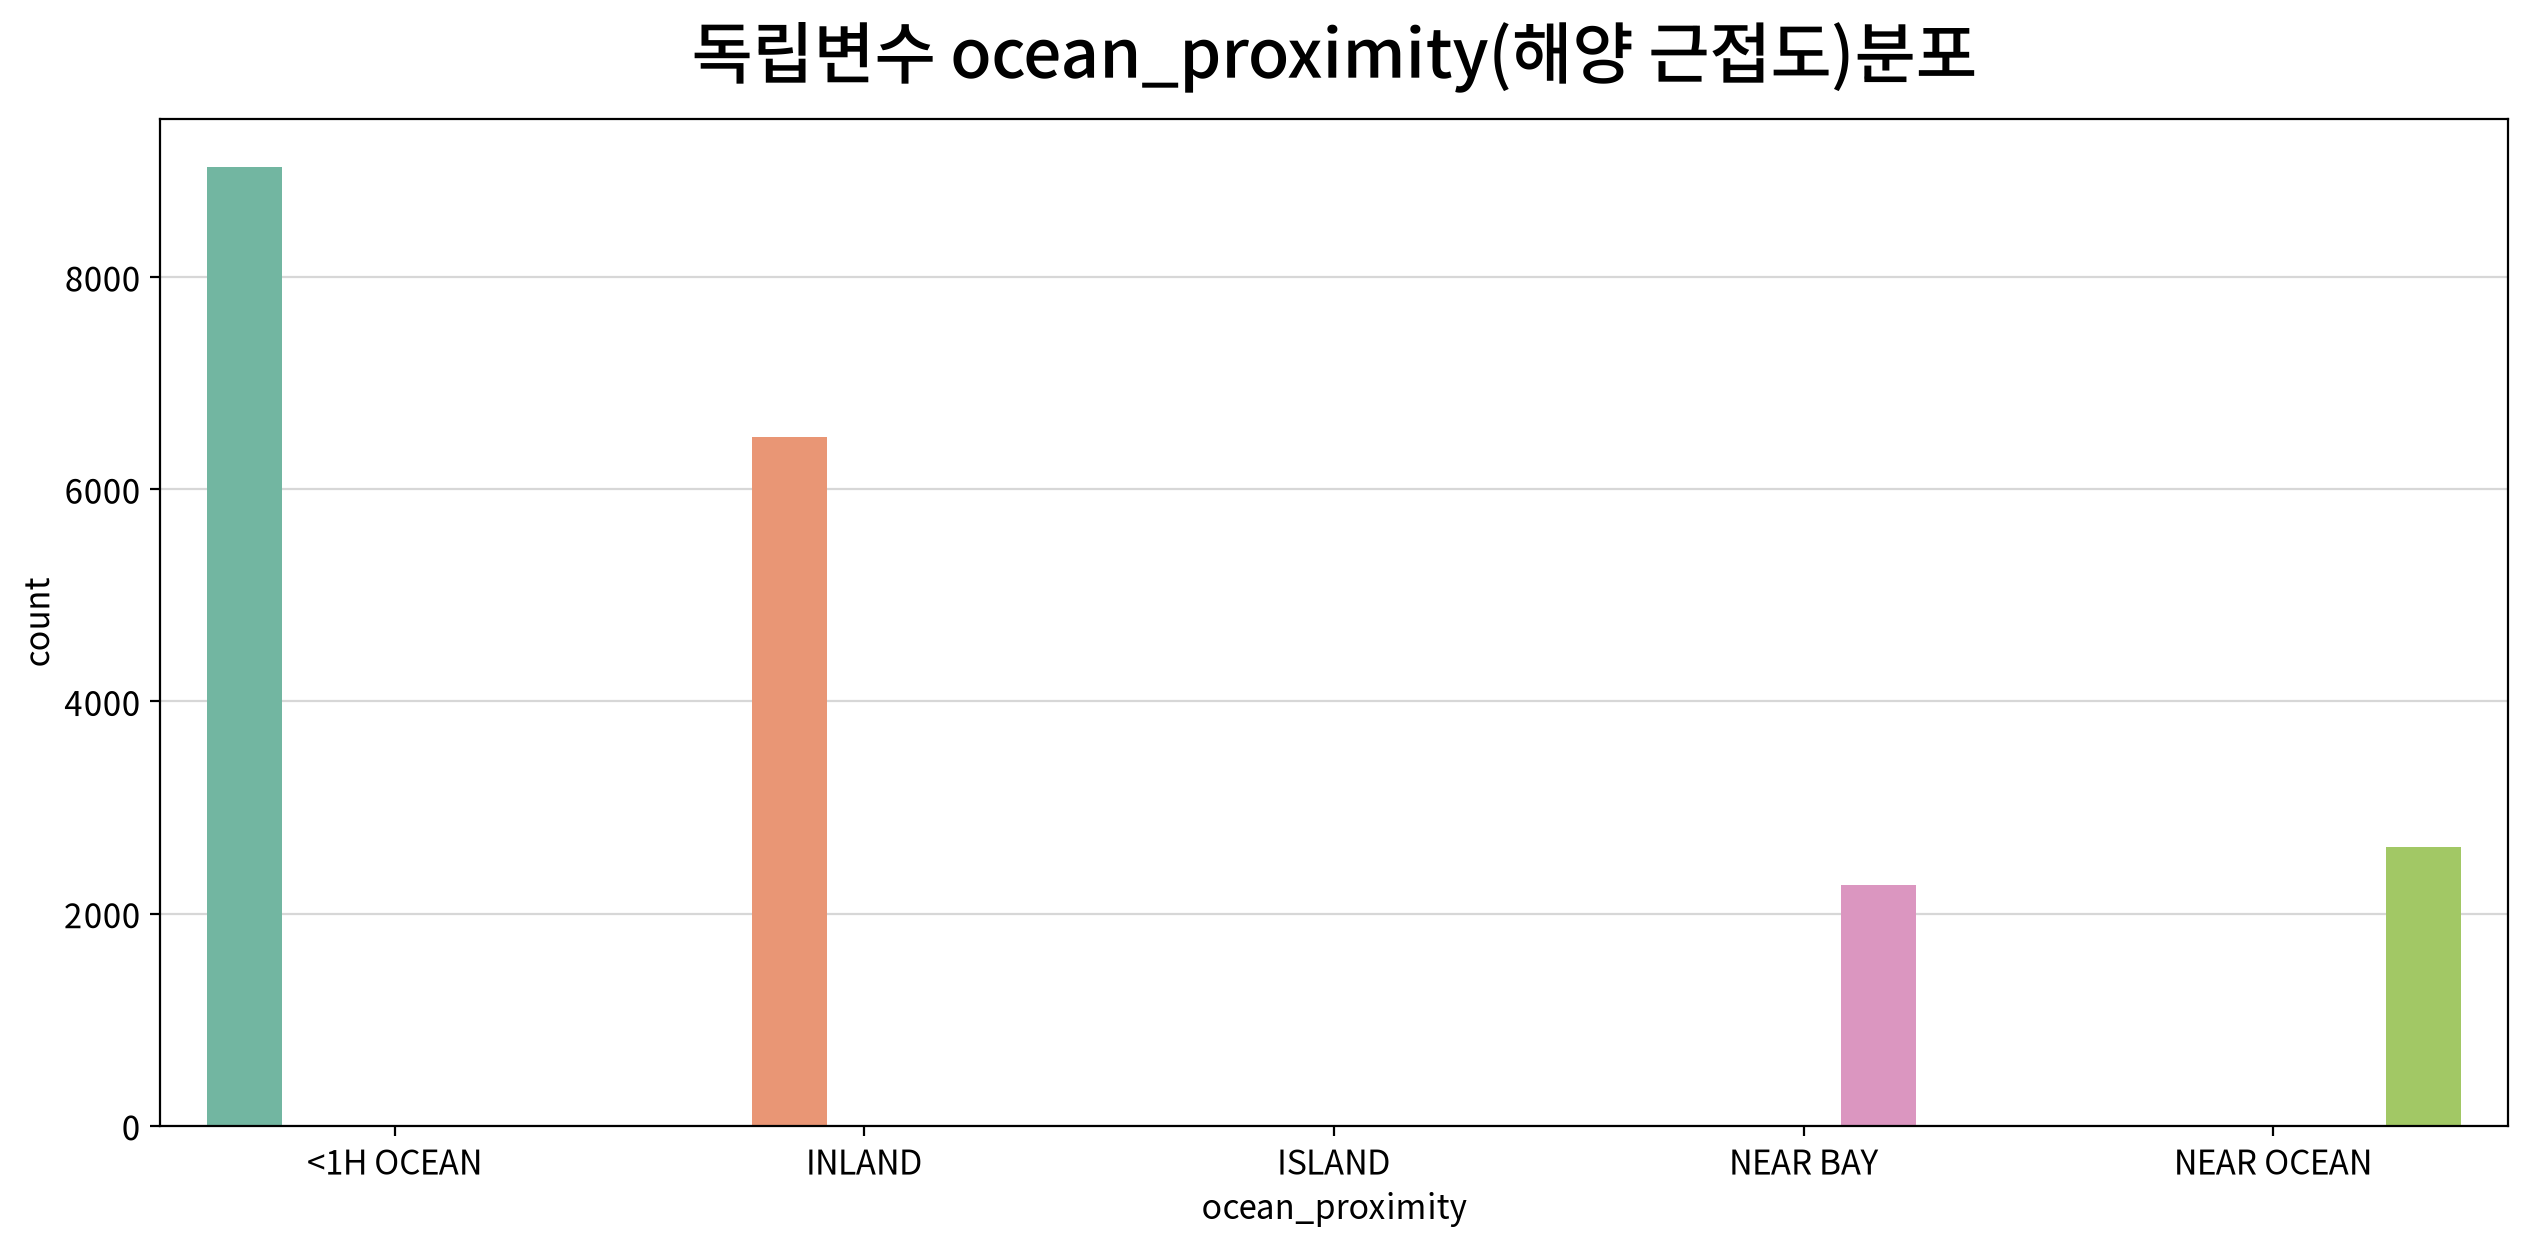

,count,unique,top,freq
ocean_proximity,20433,5,<1H OCEAN,9034


,빈도,비율
ocean_proximity,,
<1H OCEAN,9034,0.442
INLAND,6496,0.318
NEAR OCEAN,2628,0.129
NEAR BAY,2270,0.111
ISLAND,5,0.000


In [10]:
for n in nominal_cols:
    # 범주형 분포는 카운트 플롯으로 처리한다 
    my_plot.countplot(data=df, x=n, hue=n,palette="Set2", 
                      title=f"독립변수 {n}({column_means[n]})분포")

    # 범주형 기술통계량 
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성 
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)
    

# 2-3. 이변량 분석 

## #03. 이변량 분석 
### 1. 상관분석 (x:연속형 독립변수 -> y:연속형 종속변수)

#### -> housing_median_age(주택 중위 연령) -> median_house_value

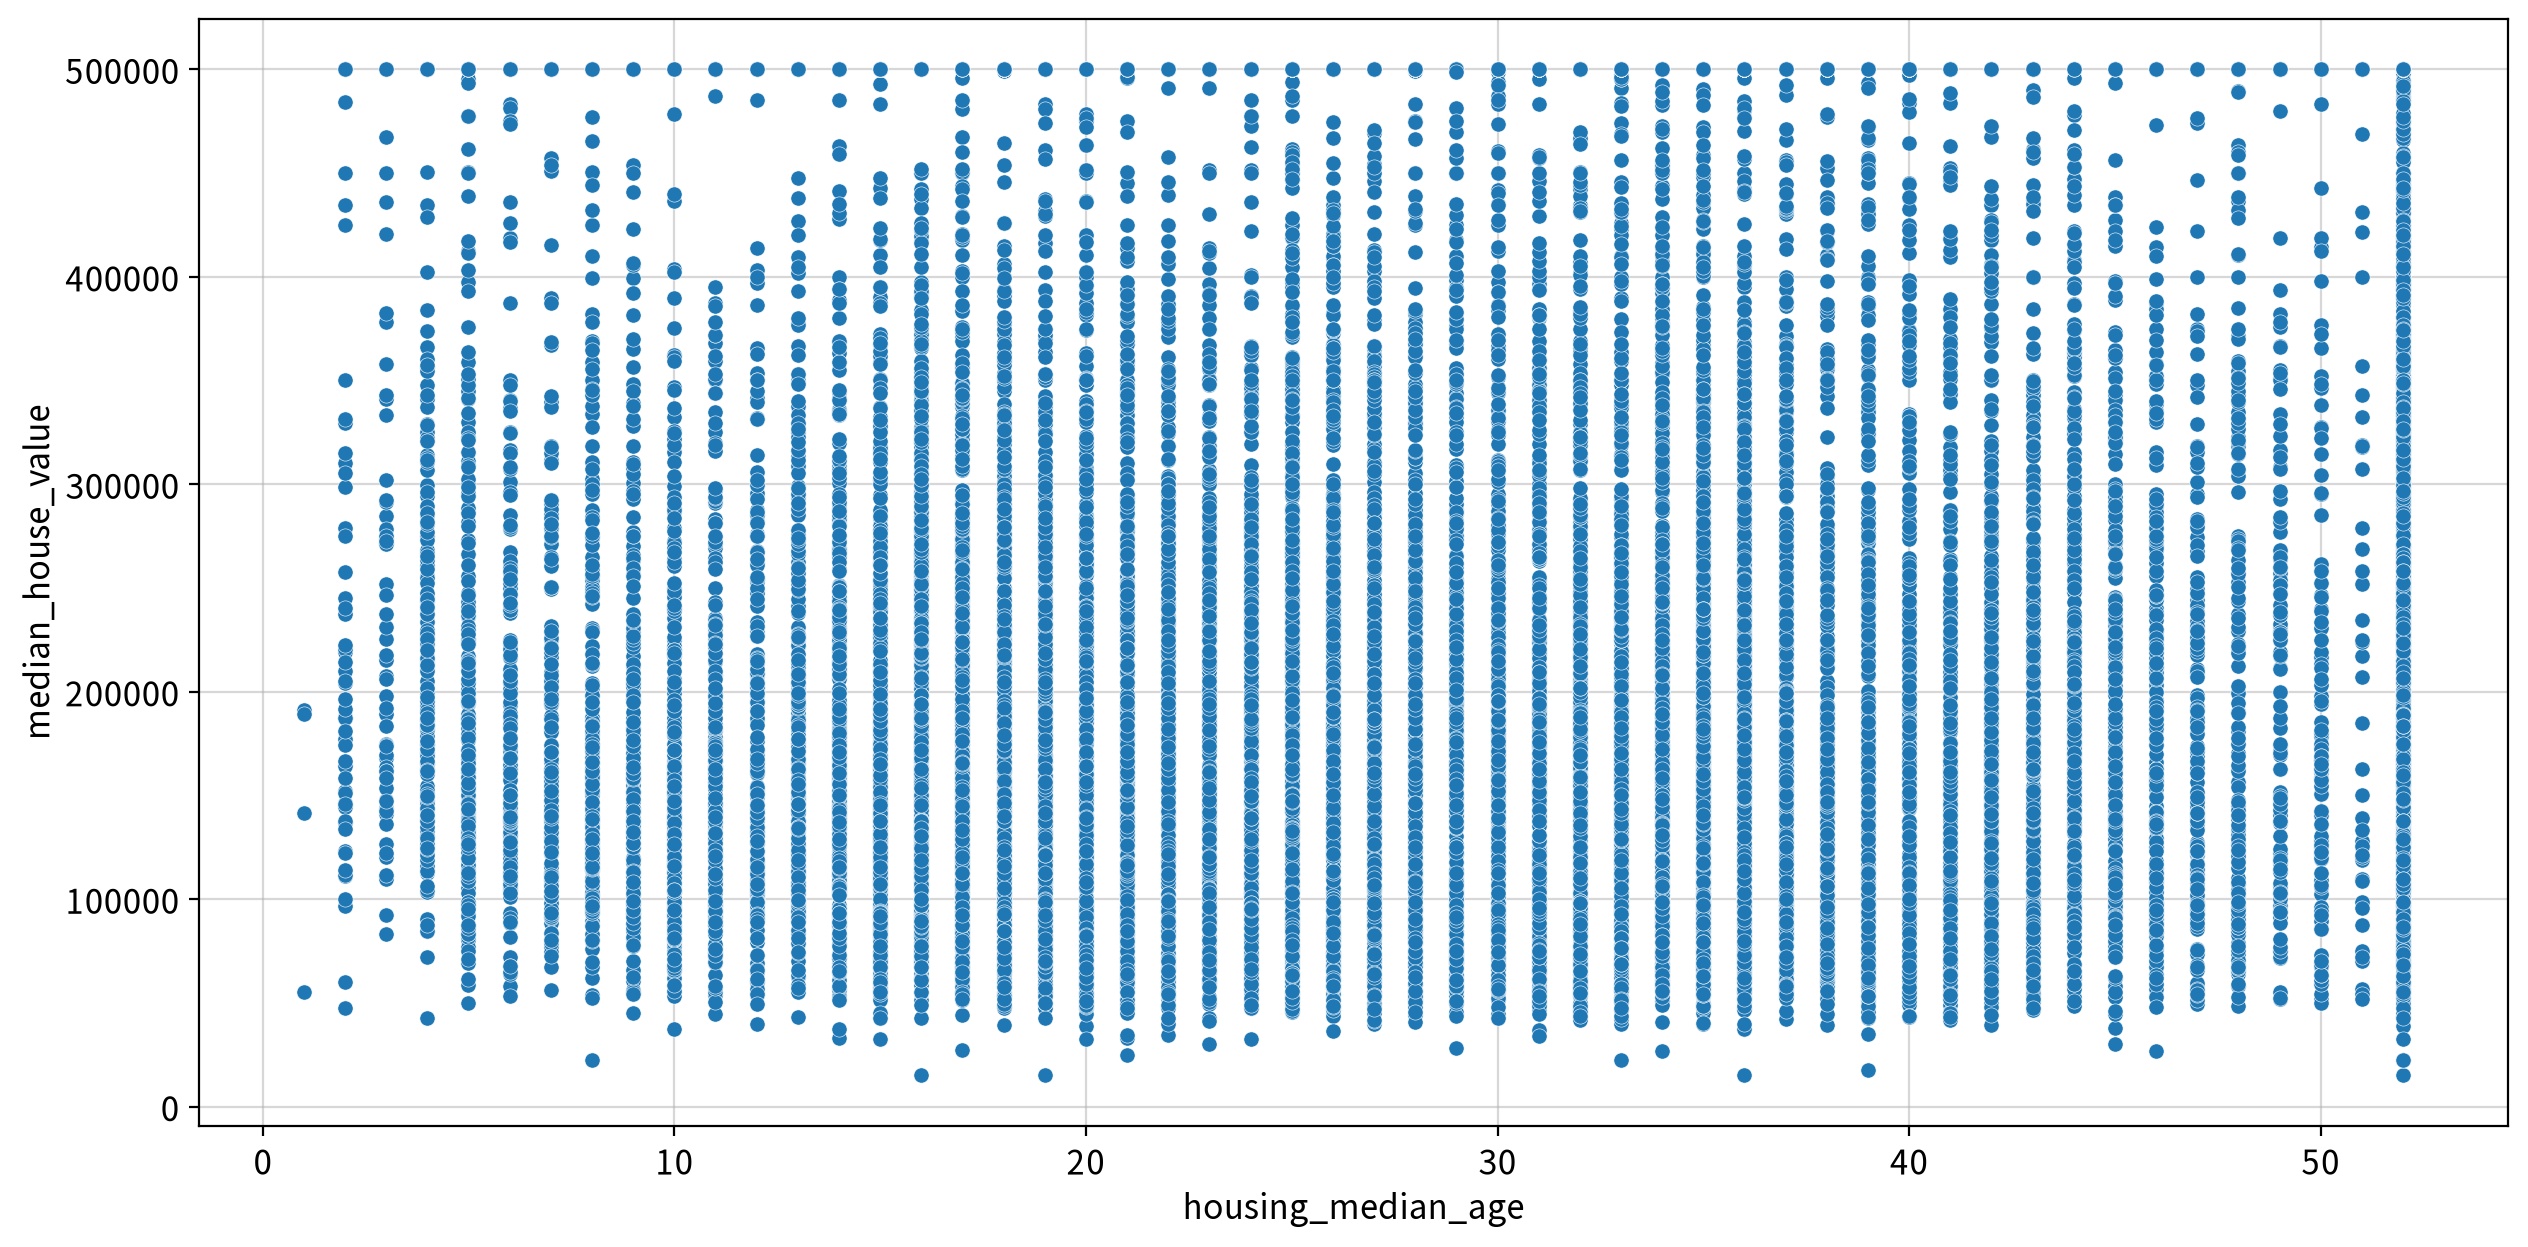

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
housing_median_age,median_house_value,Spearman,0.075,0.000,Weak,True,False,False,False,False,False


#### -> total_rooms(총 방 수) -> median_house_value

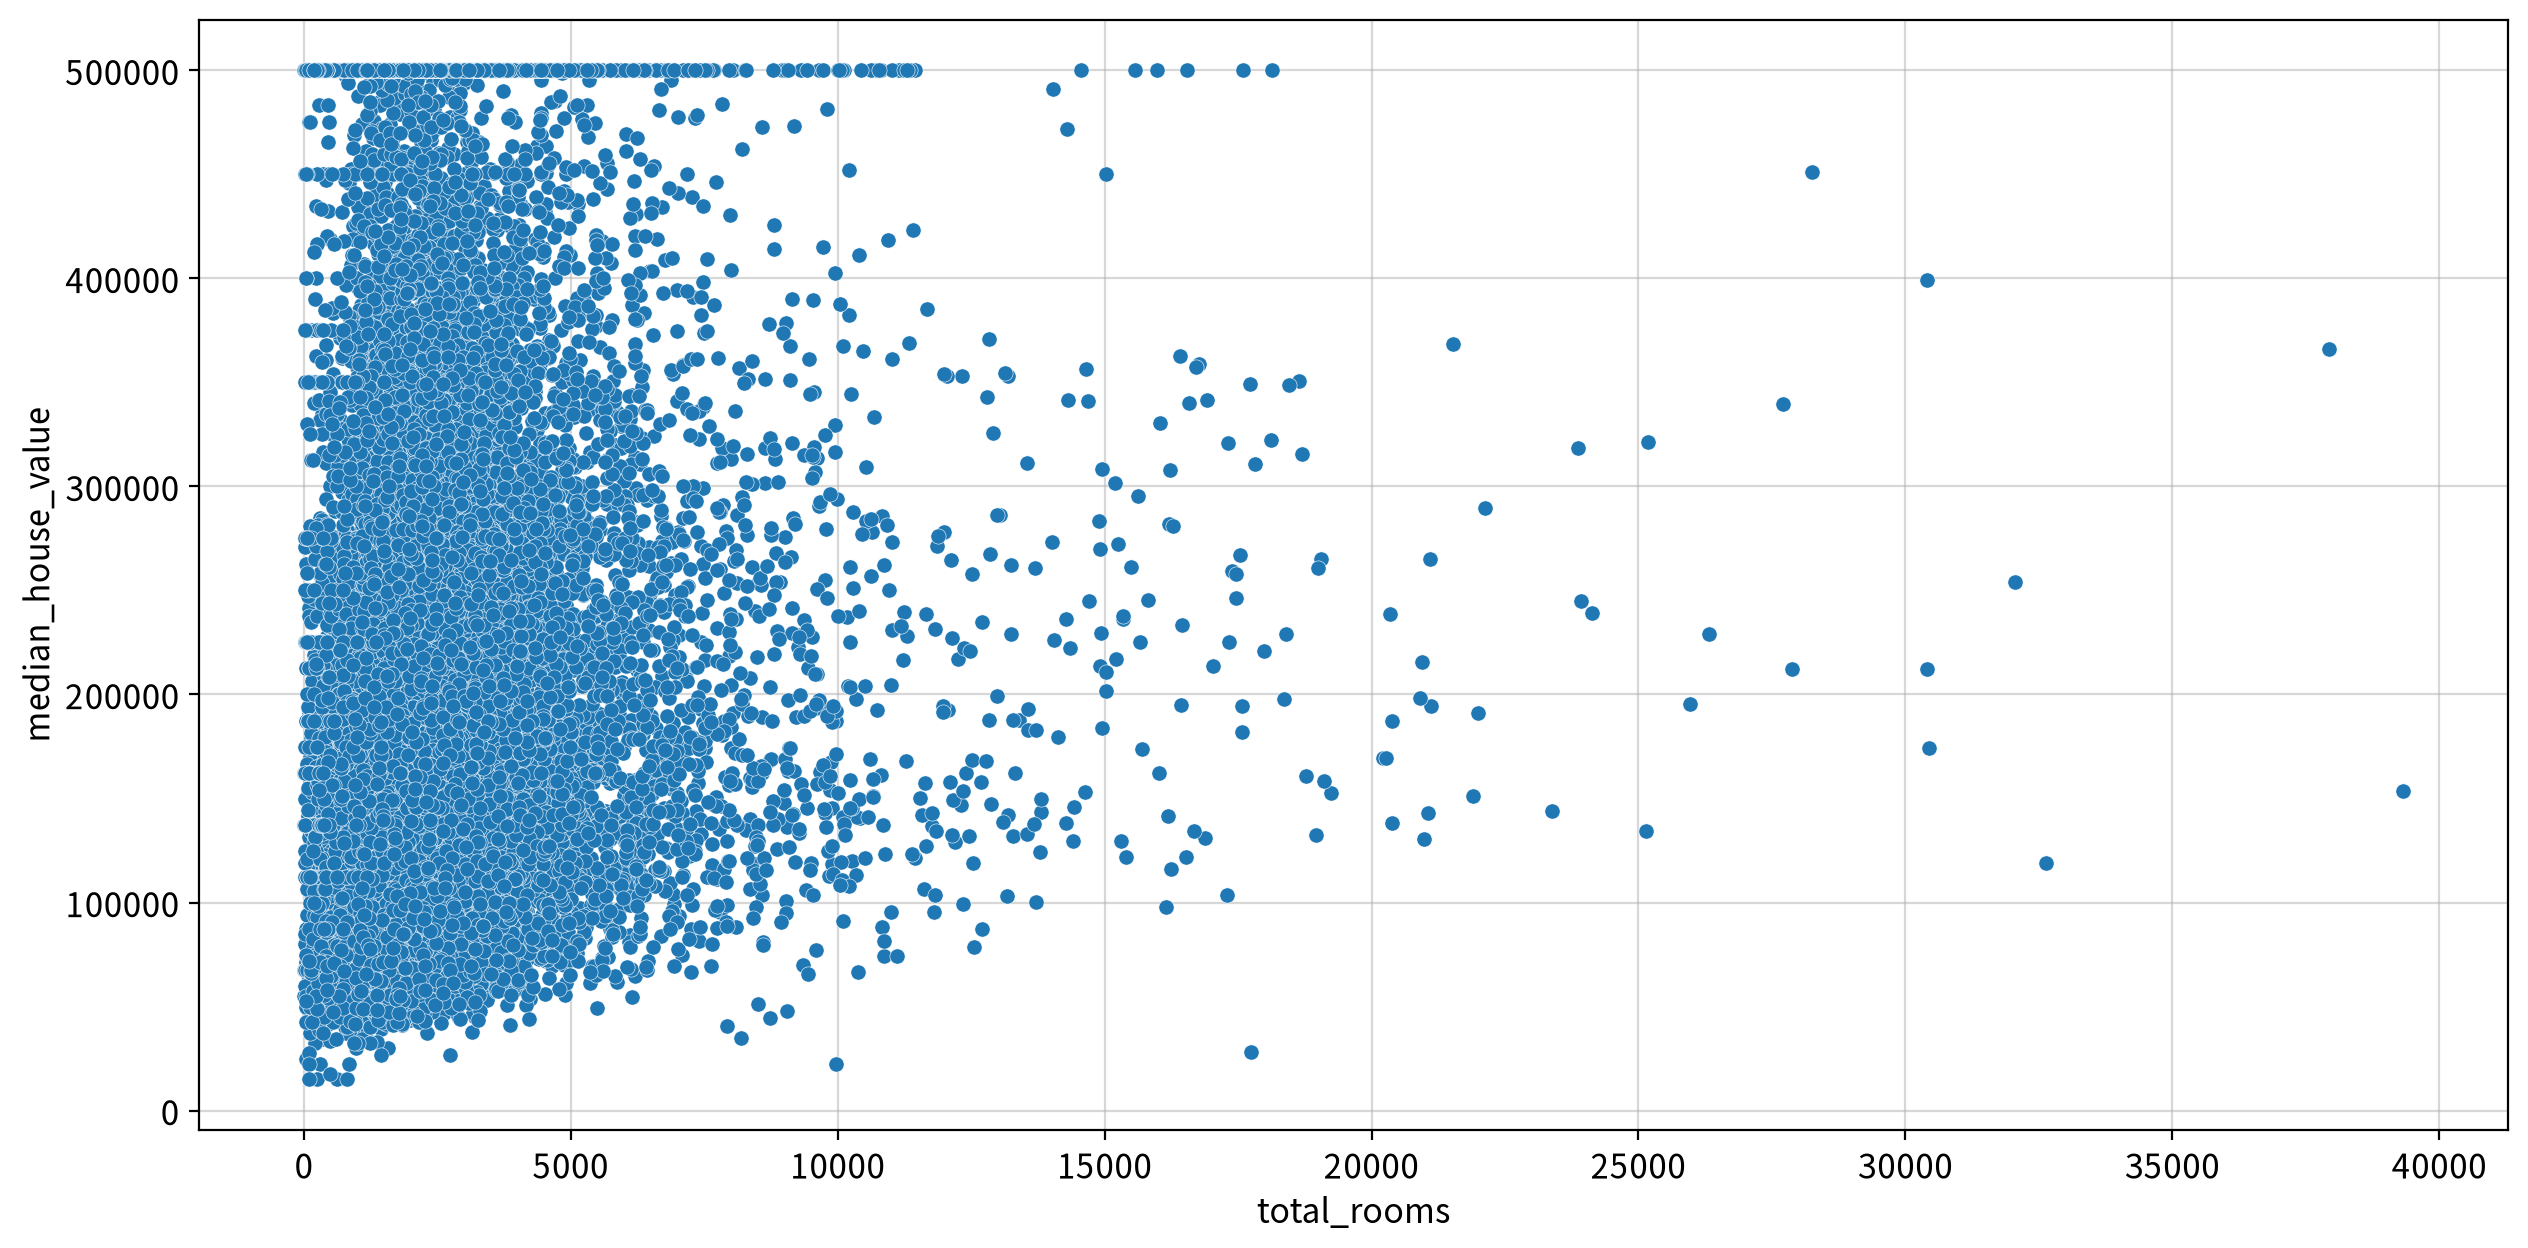

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
total_rooms,median_house_value,Spearman,0.205,0.000,Weak,True,False,False,False,False,True


#### -> total_bedrooms(총 침실 수) -> median_house_value

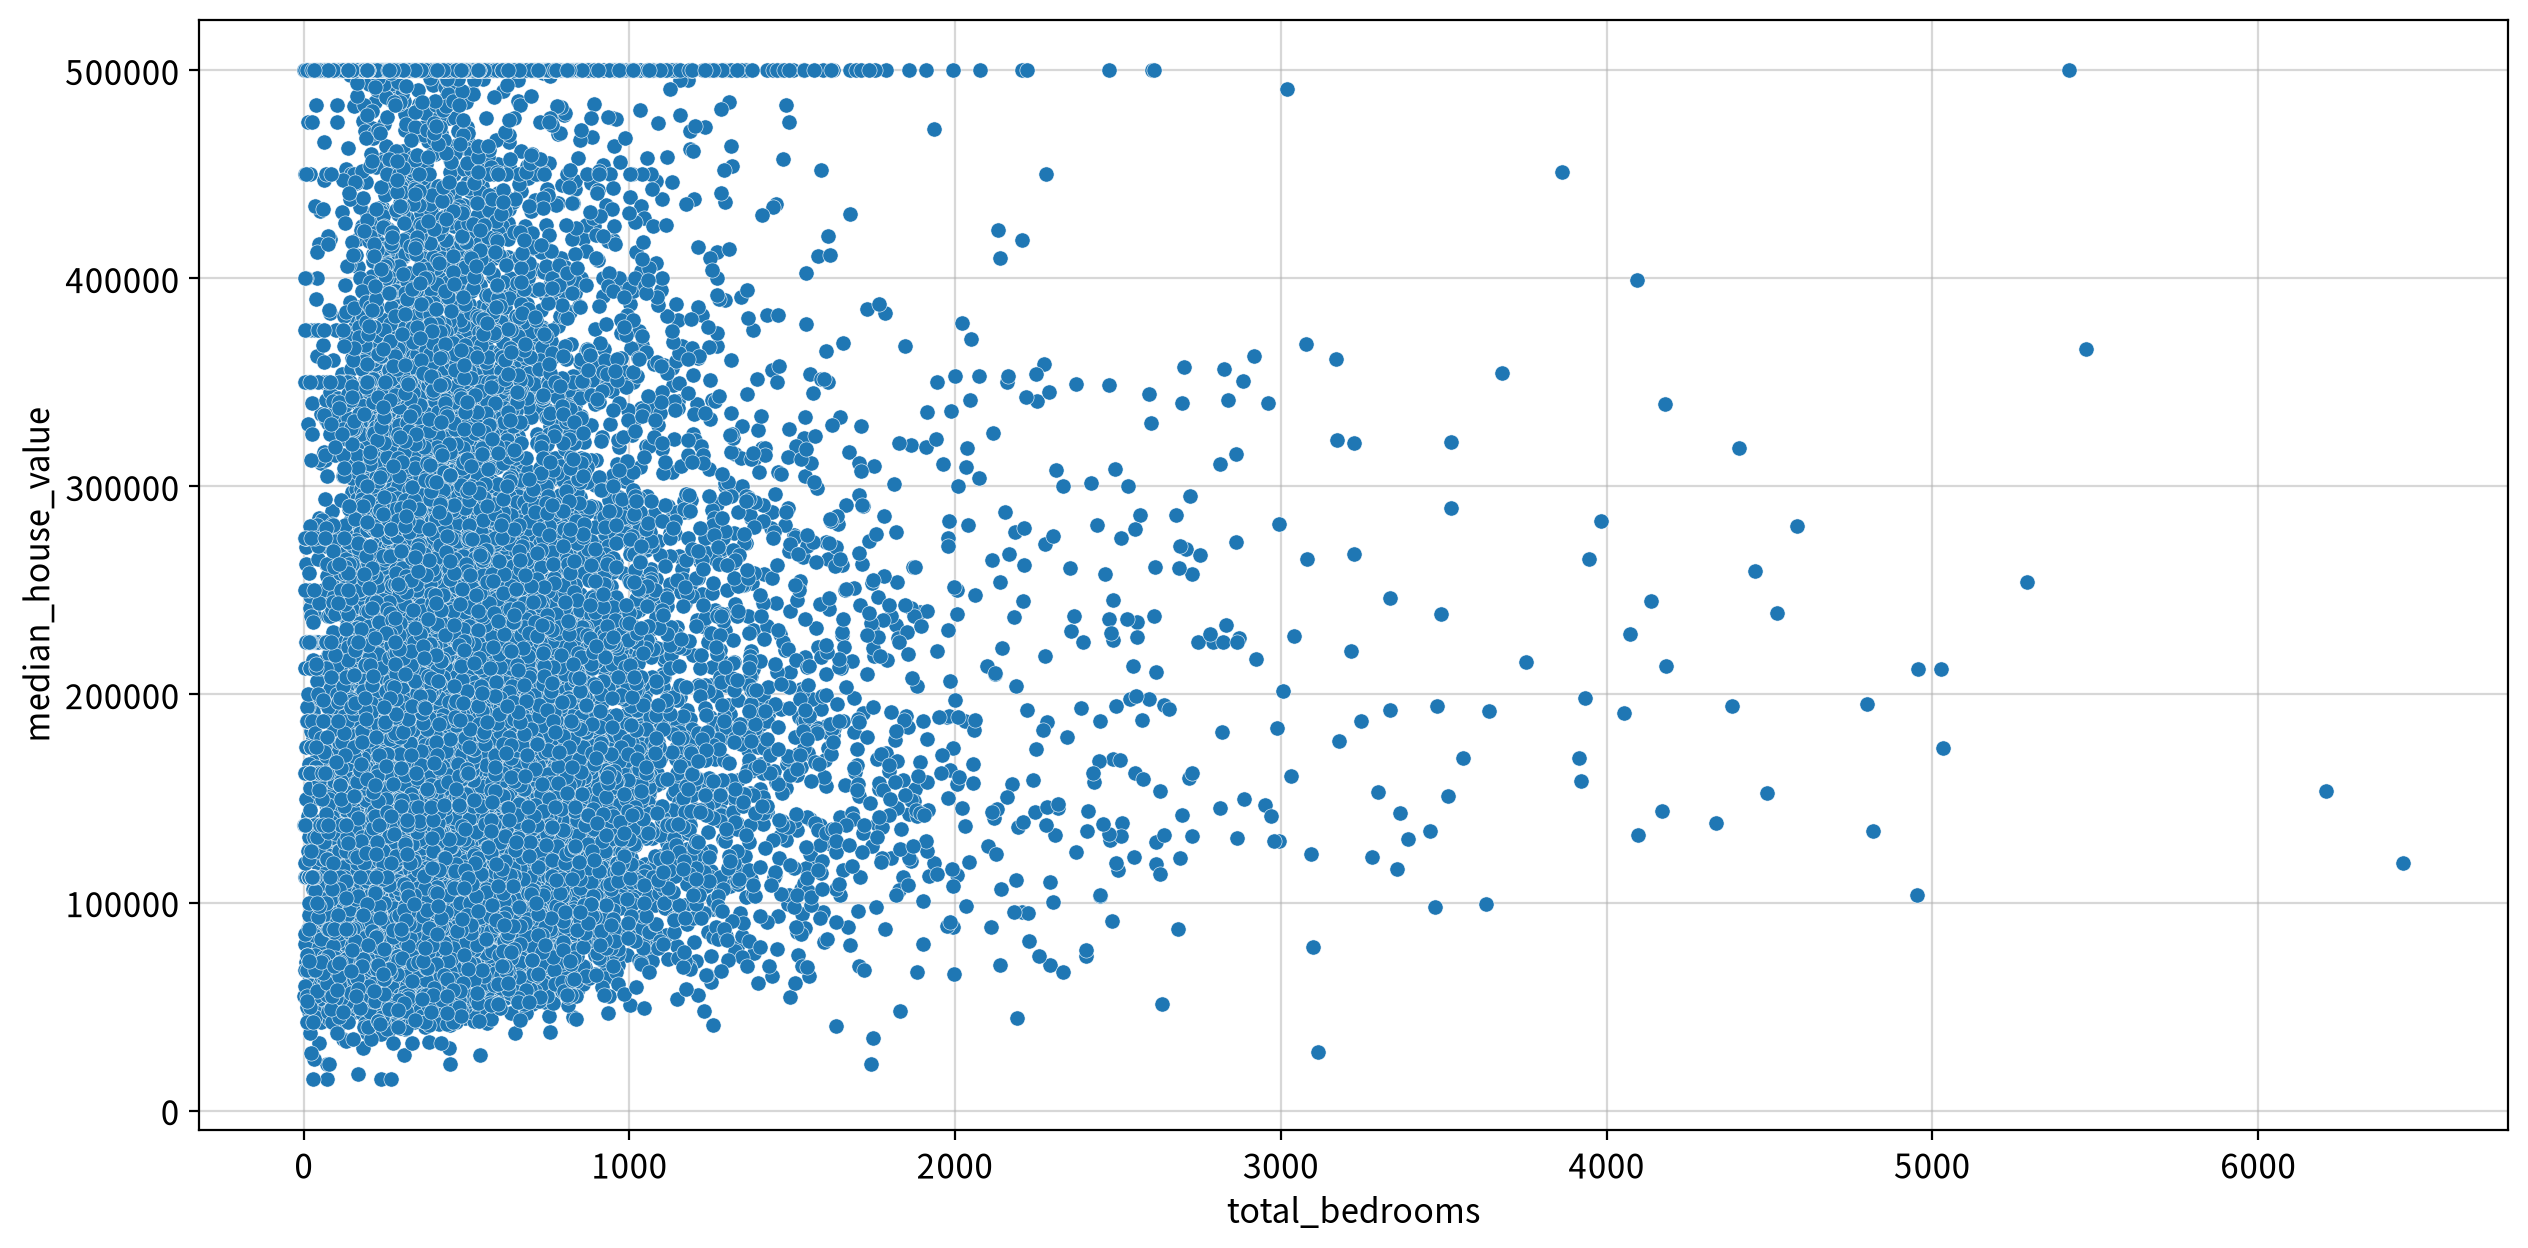

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
total_bedrooms,median_house_value,Spearman,0.086,0.000,Weak,True,False,False,False,False,True


#### -> population(인구) -> median_house_value

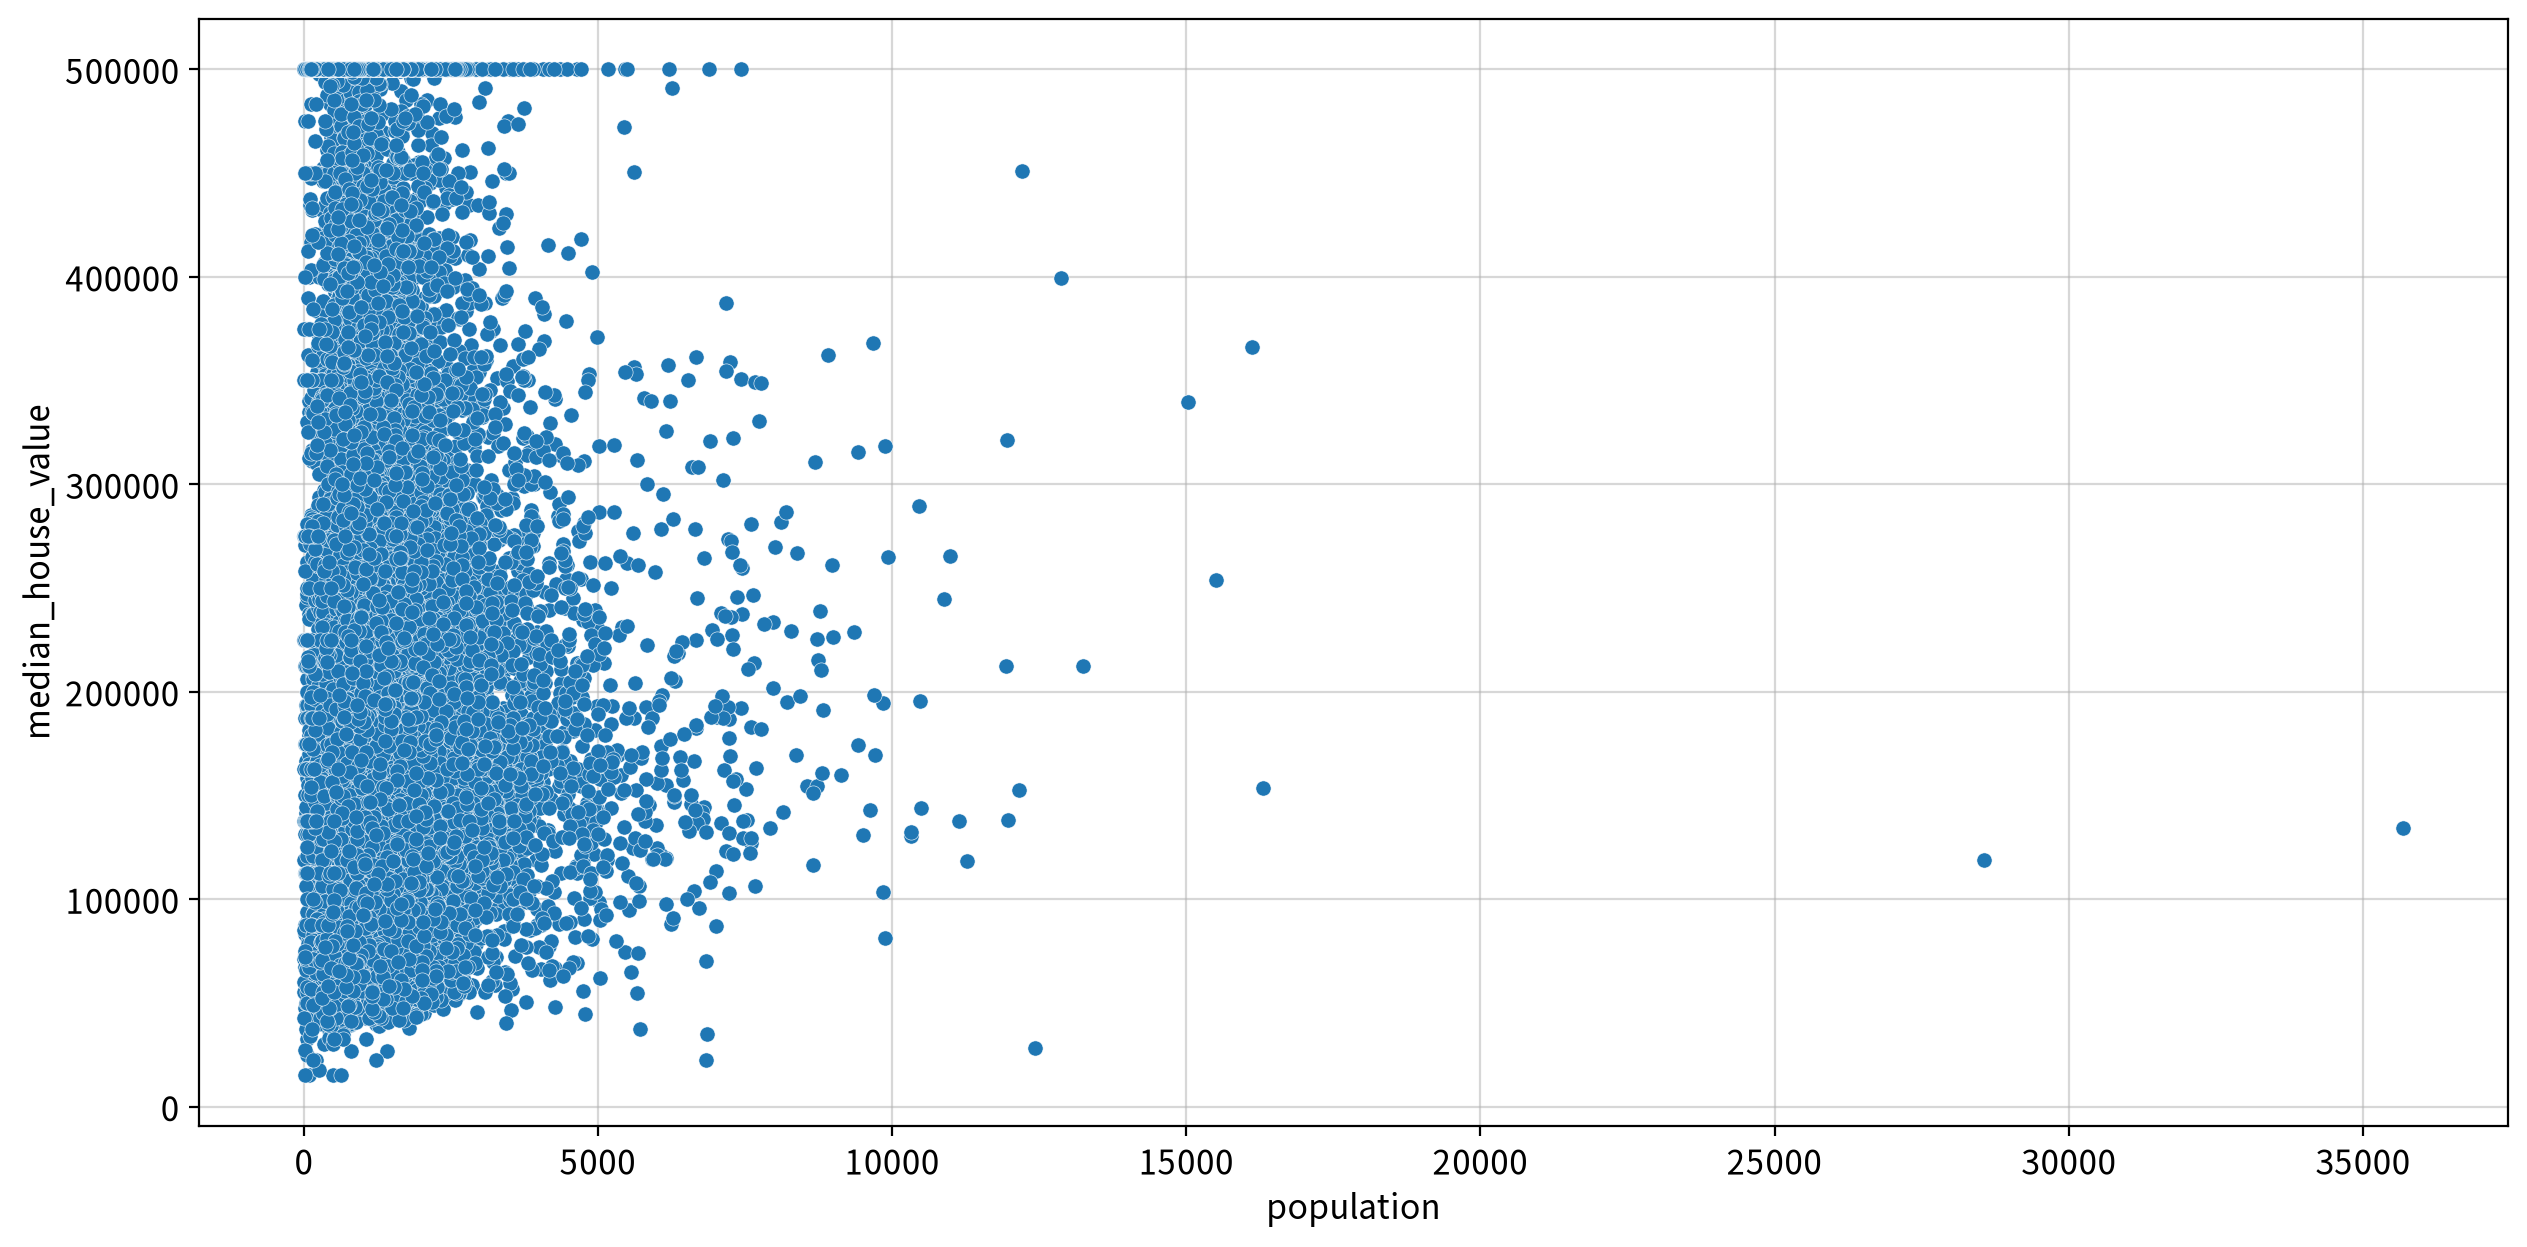

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
population,median_house_value,Spearman,0.003,0.681,Weak,False,False,False,True,False,True


#### -> households(가구 수) -> median_house_value

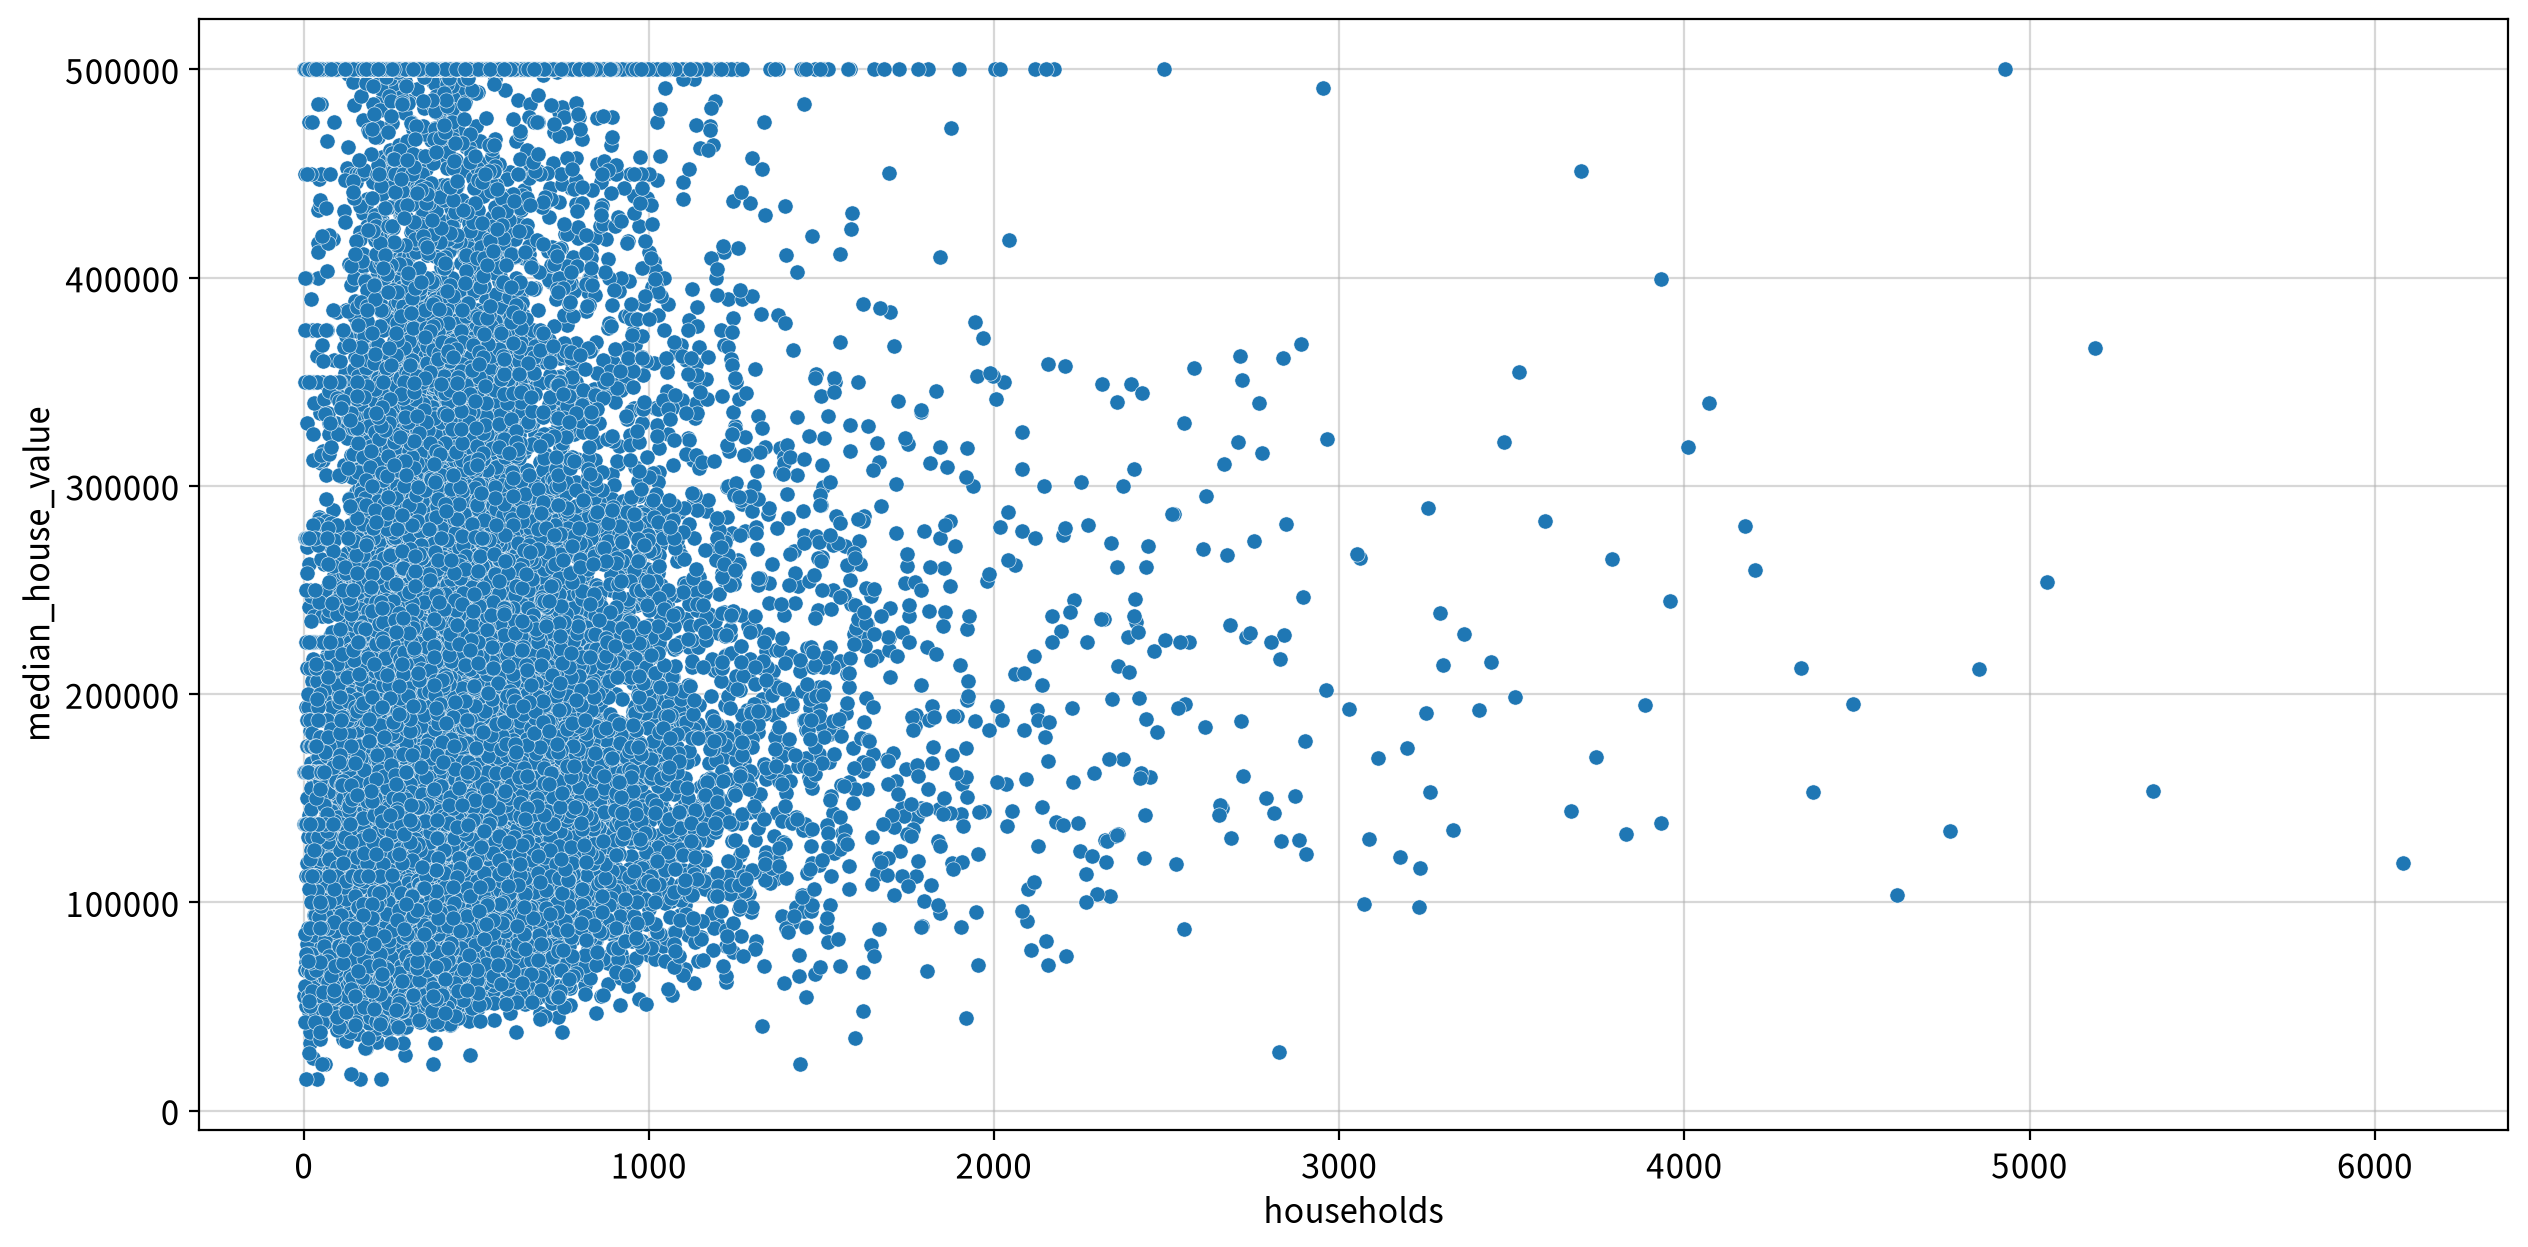

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
households,median_house_value,Spearman,0.112,0.000,Weak,True,False,False,False,False,True


#### -> median_income(중위 소득) -> median_house_value

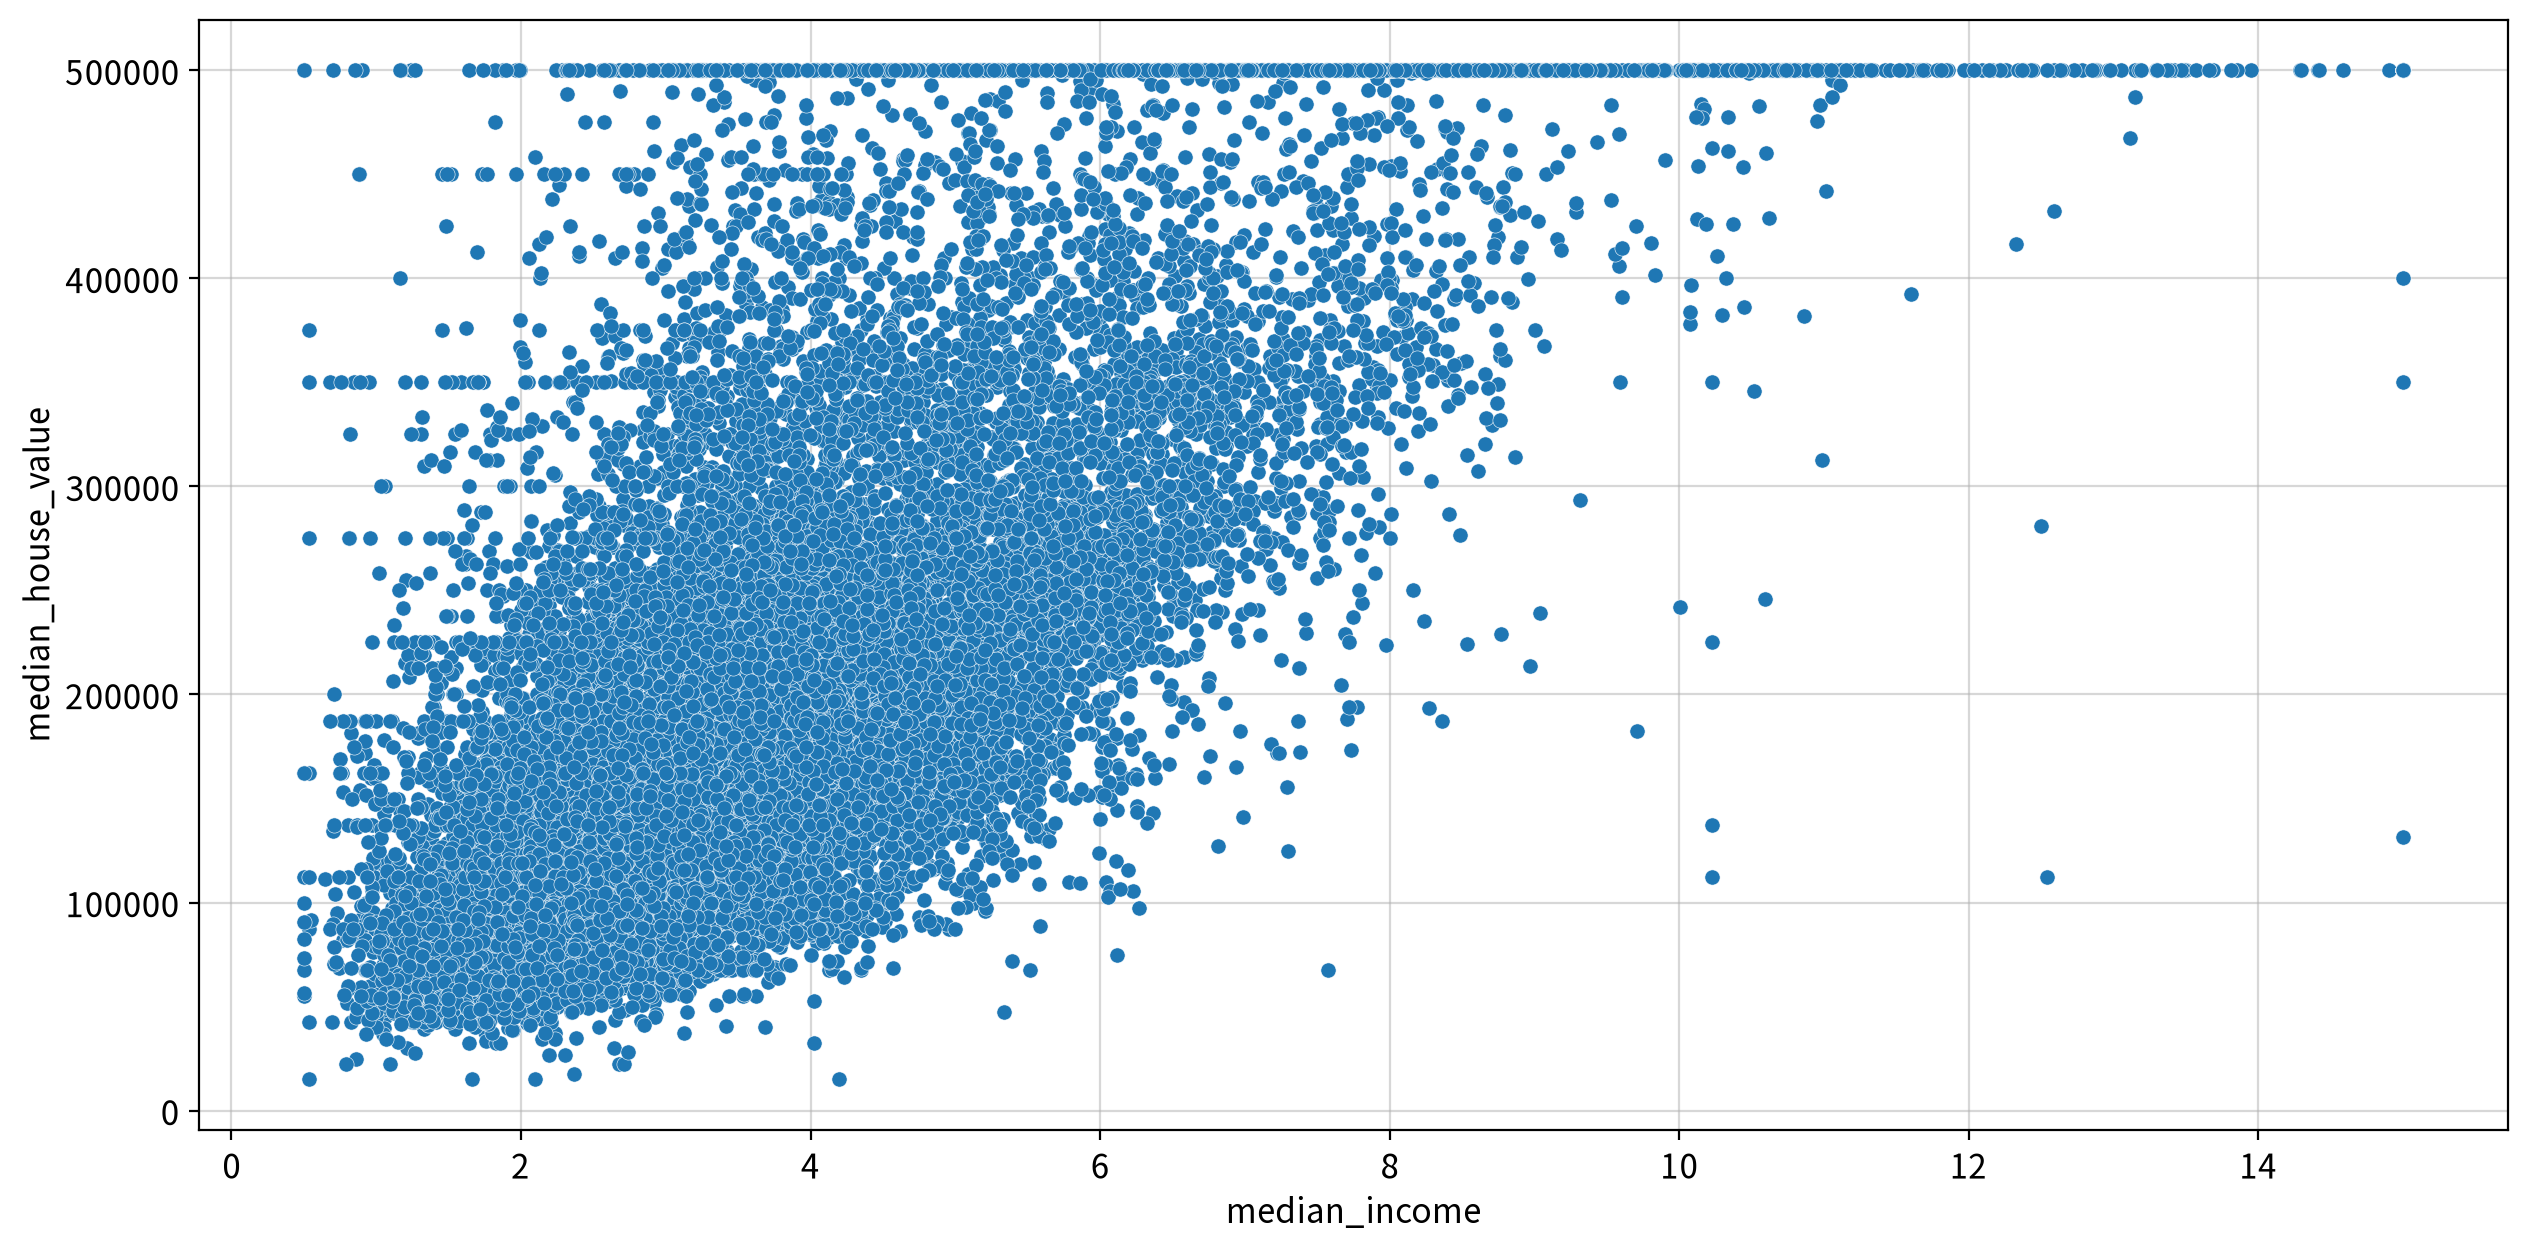

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
median_income,median_house_value,Spearman,0.677,0.000,Moderate,True,False,False,False,False,True


In [11]:
# 연속형 독립변수 이름을 탐색하면서 반복 
for f in continuous_cols:
    # 빈 줄 출력용 
    print()

    # 분석 단위 제목 출력 
    display(Markdown(f"#### -> {f}({column_means[f]}) -> {target}"))

    # 시각화 
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        # 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절 
                        linewidth=0.2, size=30)

    # my_stats는 시각화까지 일괄 처리 한다 
    display(my_stats.correlation(df, x=f, y=target, plot=False))

### 2. T-Test (x:2집단 범주형 독립변수 -> y:종속변수)

In [12]:
for n in nominal_cols:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용 
        print()

        # 분석 단위 제목 출력 
        display(Markdown(f"#### -> {n}({column_means[n]}) -> {target}"))    

        # 수집된 데이터가 long타입이므로 검정 대상만 wide 타입으로 변환해야 한다 
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                        group1=wide_df.columns[0], group2=wide_df.columns[1]))  

        

종속변수에 대한 연속형 독립변수의 상관관계
□ median_income 1종이 압도하며 population은 관계 자체가 부재함.
변수	방법·상관계수	강도	p-값	유의성	정규성	선형성	영향 이상치	강한 왜도
median_income	스피어만 0.677	중간	0.000	○	×	×	×	○
total_rooms	스피어만 0.205	약함	0.000	○	×	×	×	○
households	스피어만 0.112	약함	0.000	○	×	×	×	○
total_bedrooms	스피어만 0.086	약함	0.000	○	×	×	×	○
housing_median_age	스피어만 0.075	약함	0.000	○	×	×	×	×
population	스피어만 0.003	약함	0.681	×	×	○	×	○

상관 강도

median_income는 상관계수 0.677로 중간 강도.
2위인 total_rooms(0.205)의 3배
나머지는 약한 상관 강도를 보임

통계적 유의성

population만 유의하지 않음. p-value 0.681, coef 0.003으로 6종 중 최저.
나머지 변수는 모두 유의함.

선형성

population만 선형성을 충족하지만, 유의하지 않은 변수이므로 관계의 근거로 사용하지 않는다.

영향 이상치

6종 모두 이상치의 영향을 받지 않음.

강한 왜도

housing_median_age만 왜도가 크지 않음 (나머지 변수는 강한 왜도)
housing_median_age의 Spearman 채택 사유는 왜도가 아니라 정규성 미충족
□ 종속변수에 대한 독립변수별 산점도

절단 상한 확인

500,001$ 선의 수평 점열이 6개 산점도 모두에서 공통 관찰됨 → 절단된 데이터임을 확인.

median_income 추세

좌하→우상 방향의 추세.
점 구름 하단 경계가 x와 함께 올라가고 세로 폭 넓어짐.
나머지 5종에는 없는 방향성.

총량 변수의 쏠림

총량 3종(total_rooms·total_bedrooms·households)과 population은 좌측에 밀집하고 우측으로 긴 꼬리.

housing_median_age 줄무늬

세로 줄무늬로 나타남
x가 정수 눈금에만 값을 가지기 때문.
각 줄의 y 분포 범위는 x 전 구간에서 비슷.

### 3. ANOVA (x:3집단 범주형 독립변수 -> y:종속변수)

In [13]:
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다 
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용 

        # 분석 단위 제목 출력 
        display(Markdown(f"#### -> {n}({column_means[n]}) -> {target}"))    

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다 
        display(my_stats.anova_oneway(df, y=target, between=n)) 

        # 사후검정 
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))   
        

#### -> ocean_proximity(해양 근접도) -> median_house_value

c:\py_temp\15_LAB\helpers\my_stats.py:82: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,ocean_proximity,4,31.918,2055.803,0.000,0.238,Large


c:\py_temp\15_LAB\helpers\my_stats.py:82: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


비교한 조합 쌍: 10개
유의한 쌍: 7개
평균 차이가 가장 큰 쌍: (INLAND) vs (ISLAND)-> 차이 255543.137, 효과크기 Large, p-value 0.010
평균 차이가 가장 작은 쌍: (<1H OCEAN) vs (NEAR OCEAN)-> 차이 8774.364, 효과크기 Negligible, p-value 0.008


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,<1H OCEAN,INLAND,240267.991,124896.863,115371.128,1415.614,81.499,15420.197,0.000,1.243,True,Large
1,Games-Howell,<1H OCEAN,ISLAND,240267.991,380440.000,-140172.009,36044.653,-3.889,4.008,0.076,-1.320,False,Large
2,Games-Howell,<1H OCEAN,NEAR BAY,240267.991,259279.292,-19011.301,2810.217,-6.765,3172.951,0.000,-0.173,True,Negligible
3,Games-Howell,<1H OCEAN,NEAR OCEAN,240267.991,249042.355,-8774.364,2638.754,-3.325,3846.759,0.008,-0.080,True,Negligible
4,Games-Howell,INLAND,ISLAND,124896.863,380440.000,-255543.137,36037.816,-7.091,4.005,0.010,-3.647,True,Large
5,Games-Howell,INLAND,NEAR BAY,124896.863,259279.292,-134382.429,2721.117,-49.385,2801.345,0.000,-1.547,True,Large
6,Games-Howell,INLAND,NEAR OCEAN,124896.863,249042.355,-124145.492,2543.654,-48.806,3343.938,0.000,-1.404,True,Large
7,Games-Howell,ISLAND,NEAR BAY,380440.000,259279.292,121160.708,36119.489,3.354,4.041,0.118,0.986,False,Large
8,Games-Howell,ISLAND,NEAR OCEAN,380440.000,249042.355,131397.645,36106.554,3.639,4.035,0.093,1.072,False,Large
9,Games-Howell,NEAR BAY,NEAR OCEAN,259279.292,249042.355,10236.937,3516.182,2.911,4789.540,0.030,0.083,True,Negligible


ANOVA 결과
□ ocean_proximity가 본 데이터에서 가장 강한 설명변수

기법 Welch ANOVA · F = 2,055.803 · p < 0.001 · 효과크기 np² = 0.238 (Large)

범주	평균 집값	관측치 수
INLAND (내륙)	124,897$	6,496
<1H OCEAN (해안 1시간 이내)	240,268$	9,034
NEAR OCEAN (해안 근접)	249,042$	2,628
NEAR BAY (만 근접)	259,279$	2,270
ISLAND (섬)	380,440$	5

종속변수 분산 중 이 변수 하나가 설명하는 비율: 23.8%

np²=0.238은 종속변수 분산의 23.8%를 본 변수 단독으로 설명함을 의미. 연속형 최강인 median_income(p=0.677)에 필적하거나 그 이상임
INLAND가 압도적으로 낮고 나머지 해안권 3개 범주는 24만~26만 달러에 밀집함.
내륙과 해안권의 격차가 11만 달러를 상회함.
Welch를 적용한 것은 집단 크기가 5건에서 9,034건까지 편차가 크고 분산이 불균일하기 때문임.
□ 사후검정 — 실질 구조는 2집단 (10쌍 중 7쌍이 유의하나, 효과크기 기준으로는 내륙 대 해안권의 2집단)
비교	p	hedges g	해석
INLAND ↔ ISLAND	0.010	3.647	Large
INLAND ↔ NEAR BAY	<0.001	1.547	Large
INLAND ↔ NEAR OCEAN	<0.001	1.404	Large
INLAND ↔ <1H OCEAN	<0.001	1.243	Large
<1H OCEAN ↔ NEAR BAY	<0.001	0.173	Negligible
NEAR BAY ↔ NEAR OCEAN	0.030	0.083	Negligible
<1H OCEAN ↔ NEAR OCEAN	0.008	0.080	Negligible
유의성만으로는 5집단이 상호 다른 것으로 보이나, 효과크기 기준에서는 결론이 상이함.
해안권 상호 간에는 통계적으로 유의해도 실질 차이는 없음.
<1H OCEAN은 9,034건, NEAR OCEAN은 2,628건으로 표본이 커서 미세한 차이도 유의하게 검출됨.
실질 구조는 5집단이 아니라 내륙(g=1.24~1.55) 대 해안권(내부 g≤0.17)의 2집단임.
해안권 3종(<1H OCEAN·NEAR OCEAN·NEAR BAY)은 통계적으로 유의해도 효과크기가 모두 Negligible이므로 하나로 묶는다.
ISLAND는 표본 5개로는 검정력이 없으므로 해안권에 함부로 합치지 않는다.
ISLAND 판정 불가
□ 차이의 부재가 아니라, 표본 5건으로는 검정력이 확보되지 않기 때문
ISLAND와의 비교	평균 차이	p	유의 여부
↔ INLAND	255,543$	0.010	유의
↔ <1H OCEAN	140,172$	0.076	비유의
↔ NEAR OCEAN	131,398$	0.093	비유의
↔ NEAR BAY	121,161$	0.118	비유의
ISLAND 평균은 380,440$로 5개 범주 중 최고이나 4쌍 중 1쌍만 유의함.
NEAR BAY와의 차이 121,161
는전체중앙값
179
,
700
는전체중앙값179,700의 3분의 2에 해당하는 규모임에도 p=0.118임.
원인은 표본 크기임. 5건 규모 집단은 평균의 표준오차가 커서 신뢰구간이 넓게 형성되고, 타 집단과 중첩될 경우 비유의로 판정됨.
#04. 다변량 분석
1. 독립변수간 상관분석
python
1  corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
2  my_stats.correlation_summary(corr)

상관계수 행렬

	housing_median_age	total_rooms	total_bedrooms	population	households	median_income
housing_median_age	1.000	-0.356	-0.306	-0.283	-0.281	-0.146
total_rooms	-0.356	1.000	0.915	0.871	0.906	0.271
total_bedrooms	-0.306	0.915	1.000	0.871	0.976	-0.006
population	-0.283	0.871	0.871	1.000	0.904	0.005
households	-0.281	0.906	0.976	0.904	1.000	0.029
median_income	-0.146	0.271	-0.006	0.005	0.029	1.000

요약 (max-y / max-coef / count / columns)

x	max-y	max-coef	count	columns
households	total_bedrooms	0.976	3	total_bedrooms, total_rooms, population
total_bedrooms	households	0.976	3	households, total_rooms, population
total_rooms	total_bedrooms	0.915	3	total_bedrooms, households, population
population	households	0.904	3	households, total_bedrooms, total_rooms
housing_median_age	total_rooms	-0.356	0	-
median_income	total_rooms	0.271	0	-

🔵 중복 덩어리 4종

total_rooms · total_bedrooms · population · households 4종이 하나의 덩어리를 이룬다.

🟢 중복 없는 변수

median_income(최대 0.271) · housing_median_age(최대 -0.356)는 다른 변수와 겹치지 않는 독립적인 정보.

🔗 덩어리 내부 최대 상관 쌍

households ↔ total_bedrooms 0.976 (최대) · total_rooms ↔ total_bedrooms 0.915 · population ↔ households 0.904
□ 독립변수간 관계의 형태 — 총량 변수 4종이 하나의 중복 블록을 형성, 나머지 2종은 중복 신호 없음
변수	최대 상관 상대	최대 ρ	중복 변수 수
households	total_bedrooms	0.976	3
total_bedrooms	households	0.976	3
total_rooms	total_bedrooms	0.915	3
population	households	0.904	3
housing_median_age	total_rooms	-0.356	0
median_income	total_rooms	0.271	0

※ 중복 변수 수 = 해당 변수와 |ρ| ≥ 0.80인 다른 변수의 개수
※ |ρ| ≥ 0.90 쌍 4개: 0.976, 0.915, 0.906, 0.904

중복 블록 1개

총량 4종(total_rooms·total_bedrooms·population·households)이 서로 |ρ| 0.816~0.976.
변수 4종이 완전히 상호 상관 관계임.

신호 없는 변수 2종

housing_median_age(최대 -0.356) · median_income(최대 0.271)은 중복 변수 수 0
다른 변수와 |ρ| 0.36 미만

사전 감지 결과

6개 독립변수 중 4종에 다중공선성 신호가 집중.
|ρ| ≥ 0.90 쌍 4개는 모두 이 블록 안에서 발생하고, 블록 밖 최대 |ρ|는 0.356.

이 지표의 한계

상관관계는 두 변수 쌍 단위의 지표.
3개 이상 변수가 함께 만드는 공선성은 이 표만으로는 판단할 수 없으므로, 제거 여부는 다변량 진단 단계에서 결정.

# 2-4 다변량 분석 

## #04. 다변량 분석 
### 1. 독립변수간 상관분석 

In [14]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)  
my_stats.correlation_summary(corr)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
housing_median_age,1.000,-0.356,-0.306,-0.283,-0.281,-0.146
total_rooms,-0.356,1.000,0.915,0.816,0.906,0.271
total_bedrooms,-0.306,0.915,1.000,0.871,0.976,-0.006
population,-0.283,0.816,0.871,1.000,0.904,0.005
households,-0.281,0.906,0.976,0.904,1.000,0.029
median_income,-0.146,0.271,-0.006,0.005,0.029,1.000


,max-y,max-coef,count,columns
x,,,,
households,total_bedrooms,0.976,3,"total_bedrooms, total_rooms, population"
total_bedrooms,households,0.976,3,"households, total_rooms, population"
total_rooms,total_bedrooms,0.915,3,"total_bedrooms, households, population"
population,households,0.904,3,"households, total_bedrooms, total_rooms"
housing_median_age,total_rooms,-0.356,0,-
median_income,total_rooms,0.271,0,-


최종 변수 채택
□ 채택 2종 확정, 규모 변수 4종은 후보 유지, population은 제외
채택여부	변수	효과크기	비대칭 신호	공선성 신호	근거
채택	ocean_proximity	np² 0.238 (Large)	해당 없음	X	단독 설명력 최상위→1순위
채택	median_income	p +0.677 (Moderate)	우편향 +1.65 → log	X (최대 0.271)	연속형 유일한 실질 설명변수→2순위
후보	total_rooms	p +0.205(약함)	우편향 +4.16 → log	O (0.915~0.919)	규모 축 4종 중 설명력 최상
후보	housing_median_age	p +0.075(약함)	대칭·변환 불필요	X (최대 -0.356)	중복 없이 정보 있음, 계수 최우 관심
후보	households	p +0.112(약함)	우편향 +3.41 → log	O(0.976)	설명력·중복 열위, VIF에 따라 대체 투입
후보	total_bedrooms	p +0.086(약함)	우편향 +3.46 → log	O(0.976)	설명력·중복 열위, 대표 아님
제외	population	p +0.003 (p=0.681)	우편향 +4.96	O(0.904)	유일한 비유의, 관계 자체가 없음
별도	longitude·latitude	해당 없음	해당 없음	-	좌표 변수, 파생변수 후 재검토

※ 연속형 6종은 Spearman, ocean_proximity는 Welch ANOVA · population을 제외한 전체 p < 0.05

종합 판단

1순위 2종(ocean_proximity·median_income)이 설명력의 대부분 → 위치와 소득이 집값을 결정한다는 보편적 상식과 일치
총량 변수 4종은 개별 설명력이 약하고(p<0.21) 서로 상당히 중복(p≥0.90)되므로 그대로 넘기기보다 비율 파생변수(가구당 방 수, 방당 침실 비율, 가구당 인구)로 재구성한 뒤 재평가

전처리 선행 과제

종속변수의 500,001$ 절단 구간(958건) 플래그 관리
ocean_proximity는 해안권과 비해안권으로 다시 분류
housing_median_age 52년 절단(1,265건) 인지
위경도에 의한 공간 특성 반영
종속변수 로그 변환 + 우편향 변수 log 변환 · 데이터 래핑